# **Project Name**    - DeepFER: Facial Emotion Recognition Using Deep Learning


##### **Project Type**    - Deep Learning / Computer Vision / Image Classification
##### **Contribution**    - Individual


# **Project Summary -**

DeepFER is my facial emotion recognition project for seven emotions: angry, disgust, fear, happy, neutral, sad, and surprise. I used convolutional neural networks because facial expressions depend on visual patterns around the eyes, eyebrows, cheeks, and mouth.

I first checked the dataset structure, class distribution, image quality, file hashes, and image characteristics. I removed exact duplicate hashes with conflicting labels and excluded validation images that were exact matches of training images. I then split the cleaned training pool in a stratified way into model-training and tuning-validation sets. The duplicate-safe official validation images were kept as a held-out final evaluation set.

I compared a baseline CNN, a deeper FER CNN, and EfficientNetB0 using tuning macro F1-score. Macro F1 was more useful than accuracy alone because the disgust class had far fewer images than the majority classes. After selecting the best model, I evaluated it on the held-out final set and saved the model together with its results and run metadata.

# **GitHub Link -**

GitHub Repository Link: https://github.com/I-AM-PRASHANT-VERMA/Almabetter---DeepFER-Facial-Emotion-Recognition-Using-Deep-Learning


# **Problem Statement**


The objective of this project is to build a deep learning model that can classify facial images into seven emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise. The model should learn useful visual patterns from face images, perform well on unseen data, and provide clear evaluation results using classification metrics.

This problem is important because facial emotion recognition can support human-computer interaction, customer experience analysis, mental health monitoring, learning platforms, and smart assistance systems. The project focuses on a notebook-level solution that is accurate, explainable, and executable in one run on Google Colab.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Code Cell 00: Import Libraries
# Import core libraries used across the notebook.
import os
import json
import zipfile
import random
import hashlib
from pathlib import Path
from collections import Counter
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from scipy import stats

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Keep image loading stable even if a file has minor truncation.
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Keep results more reproducible across runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Use mixed precision on GPU when available to make training faster.
try:
    if tf.config.list_physical_devices('GPU'):
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision enabled for GPU training')
except Exception as mixed_precision_error:
    print('Mixed precision was not enabled:', mixed_precision_error)

# Use a clean plotting style for all charts.
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully')


Mixed precision enabled for GPU training
Libraries imported successfully


### Dataset Loading

In [ ]:
# Code Cell 01: Mount Google Drive And Check Dataset Zip
# Mount Google Drive so the dataset zip can be read from the project folder.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('Google Drive mounting is available only inside Google Colab.')

# Keep dataset and output paths under one project folder in Drive.
PROJECT_DRIVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning')
DATASET_ZIP_PATH = PROJECT_DRIVE_DIR / 'dataset' / 'Face Emotion Recognition Dataset.zip'
LOCAL_EXTRACT_DIR = Path('/content/deepfer_dataset')
OUTPUT_DIR = PROJECT_DRIVE_DIR / 'outputs'

# Keep all generated files in one Drive output folder.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Stop early with a clear message if the required dataset archive is missing.
if not DATASET_ZIP_PATH.exists():
    raise FileNotFoundError(f'Dataset zip not found: {DATASET_ZIP_PATH}')

print('Dataset zip found:', DATASET_ZIP_PATH)
print('Output folder:', OUTPUT_DIR)


Mounted at /content/drive
Dataset zip found: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/dataset/Face Emotion Recognition Dataset.zip
Output folder: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs


In [ ]:
# Code Cell 02: Extract Dataset And Set Folder Paths
# Check the extracted folder structure before creating the image metadata.
# Extract the zip only when the local runtime folder is not ready.
train_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
validation_check_dir = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'

# Extract only when this Colab runtime does not already contain both image splits.
if not train_check_dir.exists() or not validation_check_dir.exists():
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(DATASET_ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    print('Dataset extracted successfully')
else:
    print('Dataset already extracted in the current Colab runtime')

TRAIN_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'train'
VALIDATION_DIR = LOCAL_EXTRACT_DIR / 'images' / 'images' / 'validation'
CLASS_NAMES = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])

print('Train directory:', TRAIN_DIR)
print('Validation directory:', VALIDATION_DIR)
print('Classes:', CLASS_NAMES)


Dataset extracted successfully
Train directory: /content/deepfer_dataset/images/images/train
Validation directory: /content/deepfer_dataset/images/images/validation
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### Dataset First View

In [ ]:
# Code Cell 03: Create Image Metadata Table
# Store one row per image so later checks use the same dataset view.
def build_image_metadata(split_name, split_dir):
    # Collect file details class by class so the folder name becomes the target label.
    rows = []
    for class_dir in sorted(split_dir.iterdir()):
        if class_dir.is_dir():
            for image_path in sorted(class_dir.glob('*')):
                if image_path.is_file():
                    rows.append({
                        'split': split_name,
                        'label': class_dir.name,
                        'file_name': image_path.name,
                        'file_path': str(image_path),
                        'extension': image_path.suffix.lower(),
                        'file_size_kb': image_path.stat().st_size / 1024
                    })
    return rows

# Combine training and validation metadata into one table for consistent checks.
metadata_rows = []
metadata_rows.extend(build_image_metadata('train', TRAIN_DIR))
metadata_rows.extend(build_image_metadata('validation', VALIDATION_DIR))
metadata_df = pd.DataFrame(metadata_rows)

print('Metadata table created successfully')
display(metadata_df.head())


Metadata table created successfully


,split,label,file_name,file_path,extension,file_size_kb
0,train,angry,0.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.485352
1,train,angry,1.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.650391
2,train,angry,10.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.653320
3,train,angry,10002.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.610352
4,train,angry,10016.jpg,/content/deepfer_dataset/images/images/train/a...,.jpg,1.685547


### Dataset Rows & Columns count

In [ ]:
# Code Cell 04: Count Images By Split And Emotion
# Count each emotion in each original folder before any duplicate filtering.
# Group images by split and emotion to expose class imbalance.
class_count_table = (
    metadata_df
    .groupby(['split', 'label'])
    .size()
    .reset_index(name='image_count')
)

# Count total images in each original dataset split.
split_count_table = (
    metadata_df
    .groupby('split')
    .size()
    .reset_index(name='total_images')
)

print('Image count by split')
display(split_count_table)

print('Image count by split and class')
display(class_count_table)


Image count by split


,split,total_images
0,train,28821
1,validation,7066


Image count by split and class


,split,label,image_count
0,train,angry,3993
1,train,disgust,436
2,train,fear,4103
3,train,happy,7164
4,train,neutral,4982
5,train,sad,4938
6,train,surprise,3205
7,validation,angry,960
8,validation,disgust,111
9,validation,fear,1018


### Dataset Information

In [ ]:
# Code Cell 05: Review Metadata Details
# Review metadata structure and basic file details.
print('Metadata shape:', metadata_df.shape)
print()
print('Metadata info:')
# Check column types and missing-value counts before downstream analysis.
metadata_df.info()

print()
print('File size summary in KB:')
# Review file-size spread to spot unusual image files.
display(metadata_df['file_size_kb'].describe().to_frame().T)


Metadata shape: (35887, 6)

Metadata info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   split         35887 non-null  object 
 1   label         35887 non-null  object 
 2   file_name     35887 non-null  object 
 3   file_path     35887 non-null  object 
 4   extension     35887 non-null  object 
 5   file_size_kb  35887 non-null  float64
dtypes: float64(1), object(5)
memory usage: 1.6+ MB

File size summary in KB:


,count,mean,std,min,25%,50%,75%,max
file_size_kb,35887.0,1.537764,0.158123,0.350586,1.438477,1.541016,1.639648,2.424805


#### Duplicate Values

In [ ]:
# Code Cell 06: Check Exact Duplicate Images
# Use file hashes to find byte-for-byte duplicate images.
def get_file_hash(file_path):
    # Read each image in chunks so hashing does not load the whole file at once.
    hash_obj = hashlib.md5()
    with open(file_path, 'rb') as file_obj:
        for chunk in iter(lambda: file_obj.read(8192), b''):
            hash_obj.update(chunk)
    return hash_obj.hexdigest()

# Store the hash beside every row for duplicate checks and split filtering.
metadata_df['file_hash'] = metadata_df['file_path'].apply(get_file_hash)
duplicate_image_count = metadata_df.duplicated(subset=['file_hash']).sum()
duplicate_name_count = metadata_df.duplicated(subset=['split', 'label', 'file_name']).sum()

print('Exact duplicate image count:', duplicate_image_count)
print('Duplicate file name count inside same split and class:', duplicate_name_count)


Exact duplicate image count: 1853
Duplicate file name count inside same split and class: 0


#### Missing Values/Null Values

In [ ]:
# Code Cell 07: Check Invalid Image Files
# Open every image once so unreadable files do not reach model training.
# Define the image formats that the notebook can safely process.
supported_extensions = {'.jpg', '.jpeg', '.png'}
unsupported_files = metadata_df[~metadata_df['extension'].isin(supported_extensions)]

# Verify image bytes before model loading instead of trusting the file extension.
def image_is_readable(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()
        return True
    except Exception:
        return False

# Save the readability result so invalid files can be filtered later.
metadata_df['is_readable'] = metadata_df['file_path'].apply(image_is_readable)
invalid_image_count = int((~metadata_df['is_readable']).sum())

print('Unsupported file count:', len(unsupported_files))
print('Unreadable image count:', invalid_image_count)


Unsupported file count: 0
Unreadable image count: 0


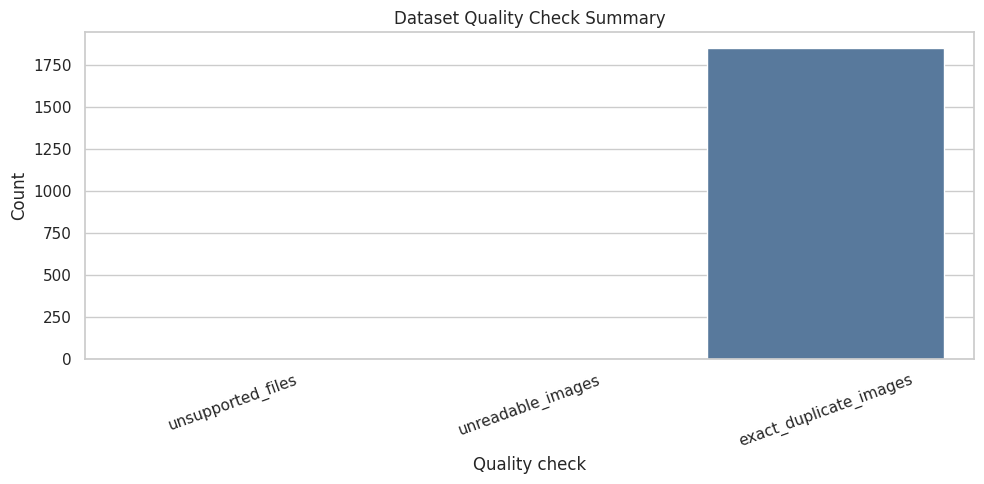

,check,count
0,unsupported_files,0
1,unreadable_images,0
2,exact_duplicate_images,1853


In [ ]:
# Code Cell 08: Visualize Data Quality Summary
# Keep the quality checks together for a quick dataset review.
# Combine duplicate and file-integrity counts into one review table.
quality_summary = pd.DataFrame({
    'check': ['unsupported_files', 'unreadable_images', 'exact_duplicate_images'],
    'count': [len(unsupported_files), invalid_image_count, int(duplicate_image_count)]
})

# Plot the checks so data issues are visible before training begins.
sns.barplot(data=quality_summary, x='check', y='count', color='#4C78A8')
plt.title('Dataset Quality Check Summary')
plt.xlabel('Quality check')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

display(quality_summary)


### What did you know about your dataset?

The dataset is an image-folder dataset with two main splits: training and validation. The output shows 28,821 training images and 7,066 validation images. Each emotion class is stored as a separate folder, so the folder name becomes the target label.

The class distribution is not balanced. Happy has the largest share, while disgust has the smallest share. This matters because a model can get reasonable accuracy by focusing on common classes, but it may still fail on rare classes. For this reason, macro F1-score, class-wise recall, prediction distribution, and confusion matrix are more useful than accuracy alone. The zip file is loaded from Google Drive and extracted into /content so Colab can read the images faster during training.

## ***2. Understanding Your Variables***

In [ ]:
# Code Cell 09: Show Metadata Columns
# Show the available metadata columns.
print('Metadata columns:')
print(metadata_df.columns.tolist())


Metadata columns:
['split', 'label', 'file_name', 'file_path', 'extension', 'file_size_kb', 'file_hash', 'is_readable']


In [ ]:
# Code Cell 10: Summarize Metadata And Label Share
# Summarize numeric fields available before model training.
display(metadata_df[['file_size_kb']].describe())

print('Label distribution percentage:')
# Calculate label share to show how much each emotion contributes to the dataset.
label_percent = metadata_df['label'].value_counts(normalize=True).mul(100).round(2)
display(label_percent.to_frame(name='percentage'))


,file_size_kb
count,35887.000000
mean,1.537764
std,0.158123
min,0.350586
25%,1.438477
50%,1.541016
75%,1.639648
max,2.424805


Label distribution percentage:


,percentage
label,
happy,25.05
neutral,17.27
sad,16.93
fear,14.27
angry,13.80
surprise,11.15
disgust,1.52


### Variables Description

The project does not contain tabular business variables. It contains image files and labels. The useful variables are created from folder structure and image metadata:

- split: identifies whether an image belongs to train or validation data.
- label: target emotion class taken from the folder name.
- file_path: exact image location used for loading.
- file_name: image file name.
- extension: file type such as .jpg.
- file_size_kb: image file size, useful for checking unusual files.
- file_hash: hash used to detect exact duplicate images.
- is_readable: tells whether the file can be opened as an image.

Later, the notebook also creates image profile features such as width, height, mean pixel value, and pixel standard deviation for EDA and hypothesis testing. These are not final model inputs; the CNN learns visual features directly from image tensors.


### Check Unique Values for each variable.

In [ ]:
# Code Cell 11: Check Unique Metadata Values
# Check unique values for key metadata columns.
# Inspect expected categories before converting labels to numeric IDs.
for column in ['split', 'label', 'extension', 'is_readable']:
    print(f'Unique values in {column}:')
    print(metadata_df[column].unique())
    print()


Unique values in split:
['train' 'validation']

Unique values in label:
['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']

Unique values in extension:
['.jpg']

Unique values in is_readable:
[ True]



## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Code Cell 12: Prepare Wrangling Objects And Image Profiles
# Keep image size aligned with the FER-style face images in this dataset.
IMG_SIZE = (48, 48)
TRANSFER_IMG_SIZE = (128, 128)
BATCH_SIZE = 128
BASELINE_EPOCHS = 8
TUNED_EPOCHS = 50
TRANSFER_HEAD_EPOCHS = 6
TRANSFER_FINE_TUNE_EPOCHS = 4
MAX_PROFILE_PER_CLASS = 80

# Create stable label-to-number mappings for all model outputs.
class_to_index = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
index_to_class = {index: class_name for class_name, index in class_to_index.items()}

# Compute class weights from the training split because the emotion classes are imbalanced.
train_labels_as_int = metadata_df.loc[metadata_df['split'] == 'train', 'label'].map(class_to_index).to_numpy()
raw_class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=train_labels_as_int
)
raw_class_weight_dict = {index: float(weight) for index, weight in enumerate(raw_class_weight_values)}

# Keep moderated weights as an imbalance diagnostic; final CNN training does not pass them to model.fit.
class_weight_dict = {
    index: float(min(np.sqrt(weight), 3.0))
    for index, weight in raw_class_weight_dict.items()
}

# Profile a fixed sample so EDA stays fast and repeatable.
profile_samples = []
for (_, _), group_df in metadata_df.groupby(['split', 'label']):
    sample_size = min(MAX_PROFILE_PER_CLASS, len(group_df))
    profile_samples.append(group_df.sample(sample_size, random_state=SEED))

profile_sample_df = pd.concat(profile_samples, ignore_index=True)

def read_image_profile(file_path):
    # Read each sampled image in grayscale and calculate simple brightness features.
    with Image.open(file_path).convert('L') as img:
        width, height = img.size
        resized_img = img.resize(IMG_SIZE)
        arr = np.asarray(resized_img, dtype=np.float32)
    return {
        'width': width,
        'height': height,
        'mean_pixel': float(arr.mean()),
        'std_pixel': float(arr.std())
    }

# Build a sampled image-profile table for EDA and hypothesis testing.
profile_records = []
for row in profile_sample_df.itertuples(index=False):
    profile = read_image_profile(row.file_path)
    profile.update({
        'split': row.split,
        'label': row.label,
        'file_path': row.file_path,
        'file_size_kb': row.file_size_kb
    })
    profile_records.append(profile)

image_profile_df = pd.DataFrame(profile_records)

# Keep augmentation realistic because strong distortions can change facial expression meaning.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.06, seed=SEED),
    layers.RandomZoom(0.08, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, seed=SEED),
    layers.RandomContrast(0.08, seed=SEED)
], name='data_augmentation')

print('Wrangling objects created successfully')
print('Class mapping:', class_to_index)
print('Raw class weights:', raw_class_weight_dict)
print('Moderated class weights:', class_weight_dict)
display(image_profile_df.head())


Wrangling objects created successfully
Class mapping: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Raw class weights: {0: 1.031125898894494, 1: 9.443315858453474, 2: 1.0034817729187702, 3: 0.5747188322565207, 4: 0.8264322991340254, 5: 0.8337962159347335, 6: 1.2846445286382884}
Moderated class weights: {0: 1.0154436955806532, 1: 3.0, 2: 1.001739373748866, 3: 0.7581021252156734, 4: 0.9090832190366432, 5: 0.9131244252207547, 6: 1.1334216023344041}


,width,height,mean_pixel,std_pixel,split,label,file_path,file_size_kb
0,48,48,107.316406,40.739243,train,angry,/content/deepfer_dataset/images/images/train/a...,1.415039
1,48,48,130.469177,54.184982,train,angry,/content/deepfer_dataset/images/images/train/a...,1.526367
2,48,48,81.891060,66.492241,train,angry,/content/deepfer_dataset/images/images/train/a...,1.444336
3,48,48,144.276917,51.366524,train,angry,/content/deepfer_dataset/images/images/train/a...,1.630859
4,48,48,95.356339,41.230492,train,angry,/content/deepfer_dataset/images/images/train/a...,1.338867


### What all manipulations have you done and insights you found?

The raw image folders were converted into a metadata table for analysis. The main manipulations were class counting, file quality checks, exact duplicate checking, class-weight calculation, and image profile sampling.

The output confirms that this is an imbalanced image classification problem. Disgust has far fewer images than the other emotions, while happy has the largest count. This imbalance directly affects evaluation, so the notebook uses macro F1-score and class-wise metrics. The class weights are kept as a diagnostic and are not applied to final CNN training. The image profiles also confirm that the images are already small 48x48 face images, which makes a FER-style CNN a suitable model choice.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

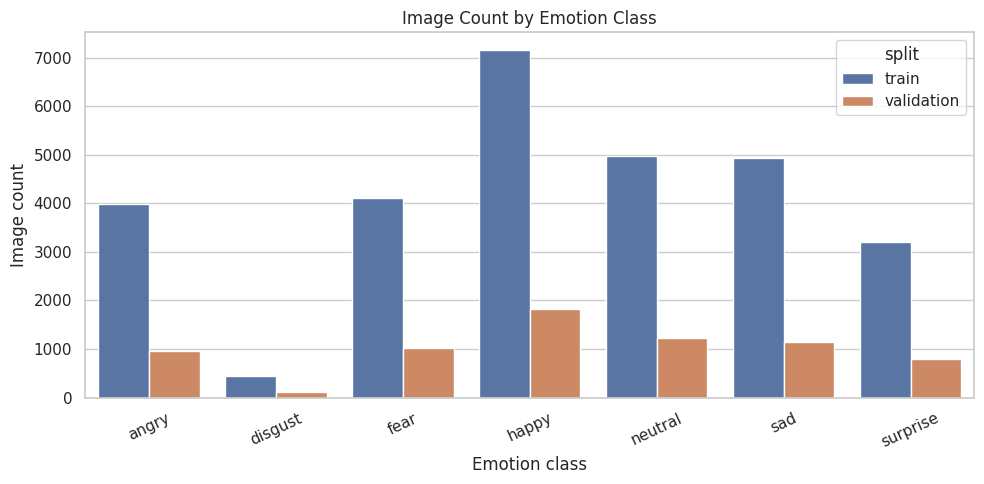

In [ ]:
# Code Cell 13: Chart 1 - Image Count By Emotion
# Use split colors to compare raw class counts between training and validation.
sns.barplot(data=class_count_table, x='label', y='image_count', hue='split')
# Label the chart clearly so raw class-count differences are easy to interpret.
plt.title('Image Count by Emotion Class')
plt.xlabel('Emotion class')
plt.ylabel('Image count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This chart was selected because class imbalance is one of the most important checks in an emotion recognition dataset. The model will see more examples of some emotions and fewer examples of others, so the chart gives an early warning about possible bias.

##### 2. What is/are the insight(s) found from the chart?

The output shows that happy has the highest image count and disgust has the lowest image count. This means the model can learn happy expressions more easily, while disgust needs special attention during evaluation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insight directly affects model design and evaluation. The class weights are used as a diagnostic, while macro F1-score and class-wise metrics are used to judge performance fairly across all emotions.

#### Chart - 2

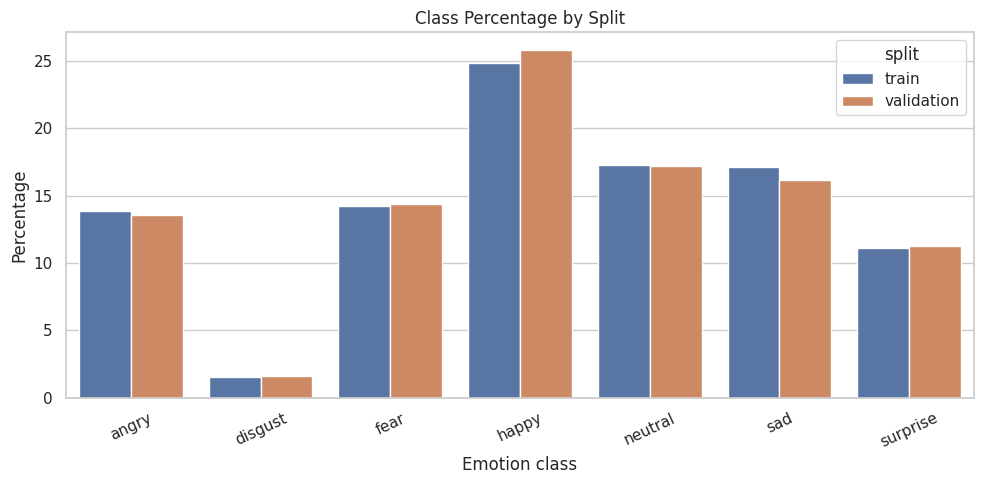

In [ ]:
# Code Cell 14: Chart 2 - Class Percentage By Split
# Convert counts into within-split percentages for a fair distribution comparison.
class_percent_table = class_count_table.copy()
class_percent_table['percentage'] = class_percent_table.groupby('split')['image_count'].transform(lambda x: x / x.sum() * 100)

# Plot percentages so unequal split sizes do not hide class-pattern differences.
sns.barplot(data=class_percent_table, x='label', y='percentage', hue='split')
plt.title('Class Percentage by Split')
plt.xlabel('Emotion class')
plt.ylabel('Percentage')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

A percentage chart was selected because percentages make train and validation distributions easier to compare than raw counts alone. It helps check whether the official validation set follows a similar class pattern to the training set.

##### 2. What is/are the insight(s) found from the chart?

The output confirms that the dataset is not evenly distributed. Happy and neutral take a much larger share than disgust. This means a high accuracy score alone can be misleading if the model ignores minority emotions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight supports the use of class-wise metrics, confusion matrix analysis, and prediction distribution checks. These outputs help verify whether the model is learning all emotions or only the dominant ones.

#### Chart - 3

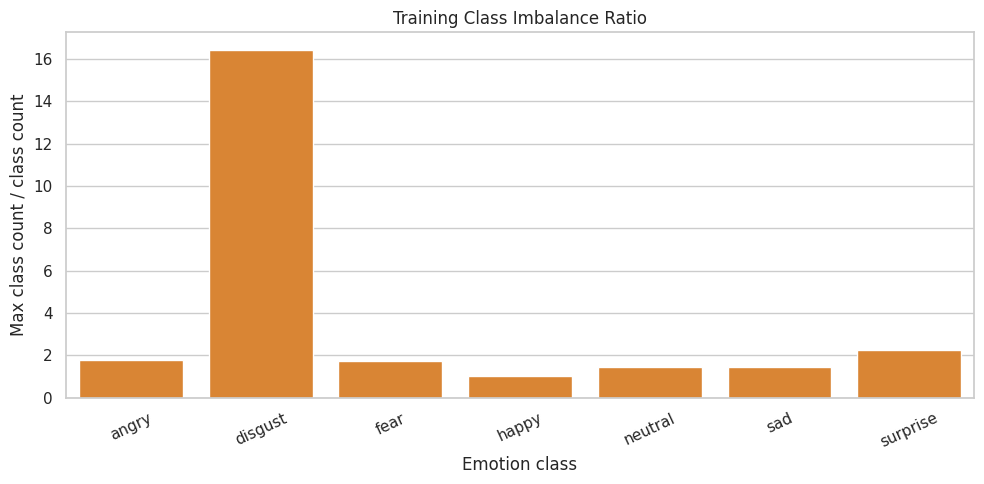

,split,label,image_count,imbalance_ratio
0,train,angry,3993,1.794140
1,train,disgust,436,16.431193
2,train,fear,4103,1.746039
3,train,happy,7164,1.000000
4,train,neutral,4982,1.437977
5,train,sad,4938,1.450790
6,train,surprise,3205,2.235257


In [ ]:
# Code Cell 15: Chart 3 - Training Imbalance Ratio
# Express every class count relative to the largest class to show imbalance clearly.
# Use only training counts when measuring the imbalance seen by the models.
train_class_counts = class_count_table[class_count_table['split'] == 'train'].copy()
max_train_count = train_class_counts['image_count'].max()
# Divide the largest class by each class count to make minority classes easy to compare.
train_class_counts['imbalance_ratio'] = max_train_count / train_class_counts['image_count']

sns.barplot(data=train_class_counts, x='label', y='imbalance_ratio', color='#F58518')
plt.title('Training Class Imbalance Ratio')
plt.xlabel('Emotion class')
plt.ylabel('Max class count / class count')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(train_class_counts)


##### 1. Why did you pick the specific chart?

The imbalance-ratio chart was selected because it shows how many times larger the biggest class is compared with each class. This makes the minority-class problem easier to understand visually.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that disgust is the most underrepresented emotion. The final training avoids aggressive class weighting because it made earlier runs unstable. Instead, it uses clean duplicate-safe data, mild augmentation, macro F1, and class-wise evaluation so minority-class performance remains visible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight is useful for building a more balanced emotion recognition system. It justifies macro F1-score and class-wise recall instead of relying only on accuracy. The class weights remain a diagnostic because aggressive weighting made earlier training unstable.

#### Chart - 4

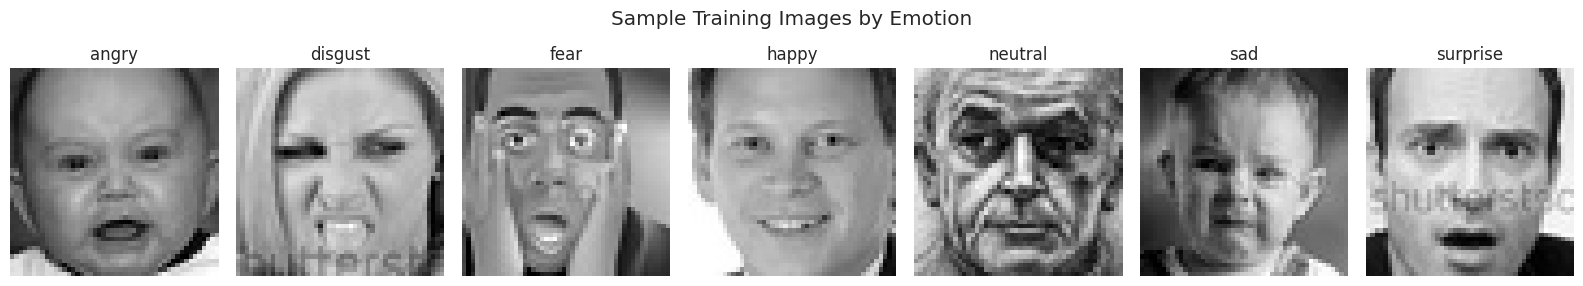

In [ ]:
# Code Cell 16: Chart 4 - Sample Images By Emotion
# Use the fixed seed so the example images remain repeatable.
# Draw one repeatable training example from every emotion class.
sample_images = (
    metadata_df[metadata_df['split'] == 'train']
    .groupby('label', group_keys=False)
    .sample(1, random_state=SEED)
    .sort_values('label')
)

# Display the selected images together for a quick visual label check.
fig, axes = plt.subplots(1, len(sample_images), figsize=(16, 3))
for axis, row in zip(axes, sample_images.itertuples(index=False)):
    image = Image.open(row.file_path).convert('L')
    axis.imshow(image, cmap='gray')
    axis.set_title(row.label)
    axis.axis('off')

plt.suptitle('Sample Training Images by Emotion')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Sample images were selected because this is a computer vision project. Before modeling, it is important to confirm that the images actually contain faces and that the labels match facial emotion expressions.

##### 2. What is/are the insight(s) found from the chart?

The sample images show grayscale face crops with visible expression areas such as eyes, eyebrows, and mouth. These are the regions the CNN should learn from. Some emotions are visually subtle, so perfect prediction should not be expected from a very small model.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Visual inspection confirms that the dataset matches the problem statement. It also supports the use of CNN models, because the useful information is in facial patterns rather than tabular columns.

#### Chart - 5

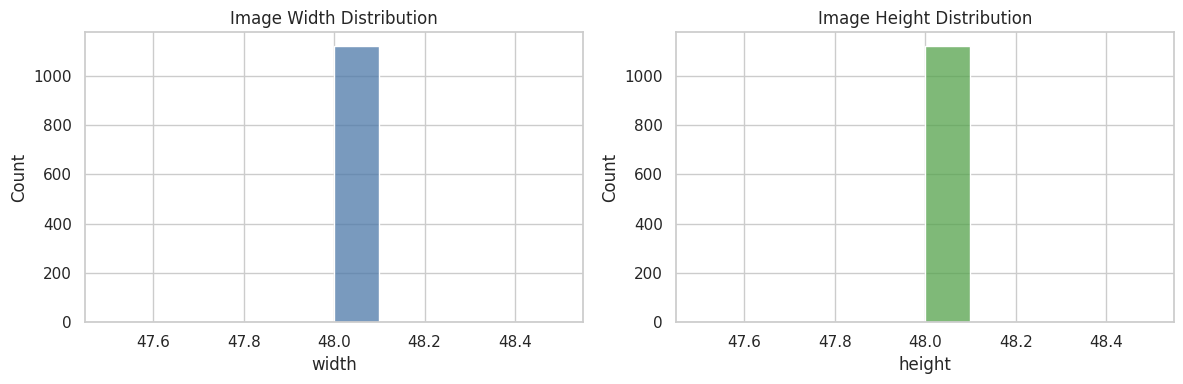

,width,height
count,1120.0,1120.0
mean,48.0,48.0
std,0.0,0.0
min,48.0,48.0
25%,48.0,48.0
50%,48.0,48.0
75%,48.0,48.0
max,48.0,48.0


In [ ]:
# Code Cell 17: Chart 5 - Image Size Distribution
# Plot sampled widths and heights to confirm the expected image shape.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=image_profile_df, x='width', bins=10, ax=axes[0], color='#4C78A8')
axes[0].set_title('Image Width Distribution')
sns.histplot(data=image_profile_df, x='height', bins=10, ax=axes[1], color='#54A24B')
axes[1].set_title('Image Height Distribution')
plt.tight_layout()
plt.show()

# Show summary statistics alongside the histograms.
display(image_profile_df[['width', 'height']].describe())


##### 1. Why did you pick the specific chart?

Image-size distribution was selected because neural networks need a consistent input shape. If image sizes vary, resizing becomes a required preprocessing step.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the images are already aligned with a compact 48x48 format. This is suitable for a FER-style CNN and keeps GPU training fast.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Consistent image sizes reduce preprocessing complexity and help the model train without shape errors. It also keeps the notebook more reliable for one-go execution.

#### Chart - 6

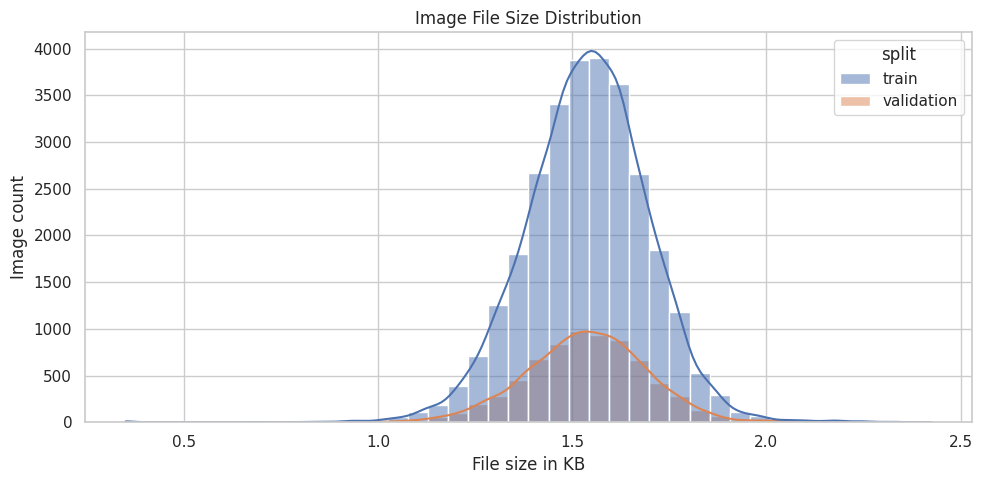

In [ ]:
# Code Cell 18: Chart 6 - File Size Distribution
# Compare file-size distributions to find unusual storage patterns between splits.
sns.histplot(data=metadata_df, x='file_size_kb', hue='split', bins=40, kde=True)
# Use the density curve to make the centre and spread of file sizes easier to compare.
plt.title('Image File Size Distribution')
plt.xlabel('File size in KB')
plt.ylabel('Image count')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

File-size distribution was selected as a data-quality check. Very small or very large files can sometimes indicate corrupted images or inconsistent data.

##### 2. What is/are the insight(s) found from the chart?

The output shows that file sizes are mostly small and close to each other, which is expected for 48x48 face images. This supports the assumption that the dataset is structurally consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This check supports data integrity. It helps confirm that model weakness is more likely due to class imbalance or visual difficulty, not broken image files.

#### Chart - 7

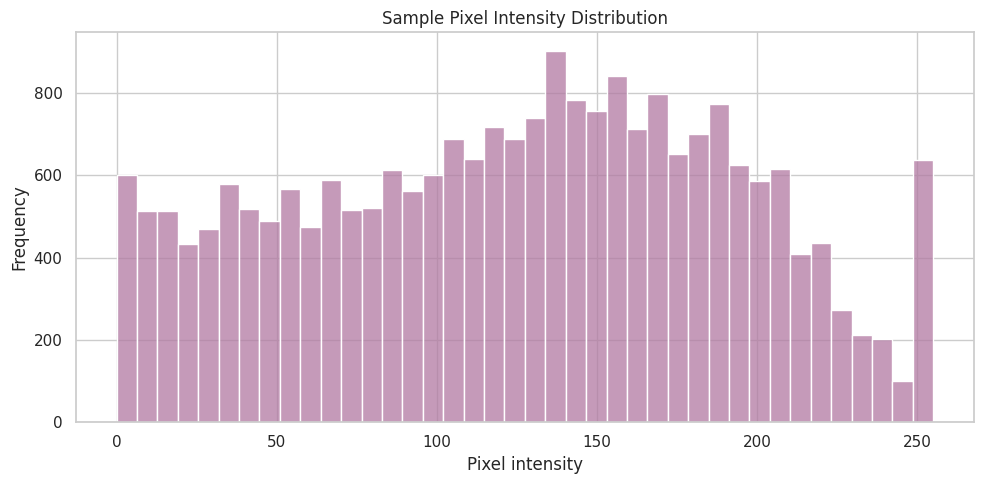

In [ ]:
# Code Cell 19: Chart 7 - Pixel Intensity Distribution
# Read dimensions from the files instead of assuming every image is identical.
# Sample image files so pixel analysis stays fast and repeatable.
sample_pixel_paths = image_profile_df.sample(min(80, len(image_profile_df)), random_state=SEED)['file_path']
pixels = []
# Flatten a subset of pixels from each image instead of storing every pixel in memory.
for file_path in sample_pixel_paths:
    arr = np.asarray(Image.open(file_path).convert('L').resize(IMG_SIZE), dtype=np.float32)
    pixels.extend(arr.ravel()[::8])

# Plot the sampled grayscale values to review overall intensity variation.
sns.histplot(pixels, bins=40, color='#B279A2')
plt.title('Sample Pixel Intensity Distribution')
plt.xlabel('Pixel intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Pixel intensity distribution was selected to understand brightness and contrast in the images. Brightness variation can affect model training if pixel values are not normalized.

##### 2. What is/are the insight(s) found from the chart?

The output shows a wide range of grayscale values. This means the model receives both dark and bright facial regions, so normalization and mild contrast augmentation are useful.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight supports pixel scaling and realistic augmentation. It helps the model handle lighting variation without changing the original dataset.

#### Chart - 8

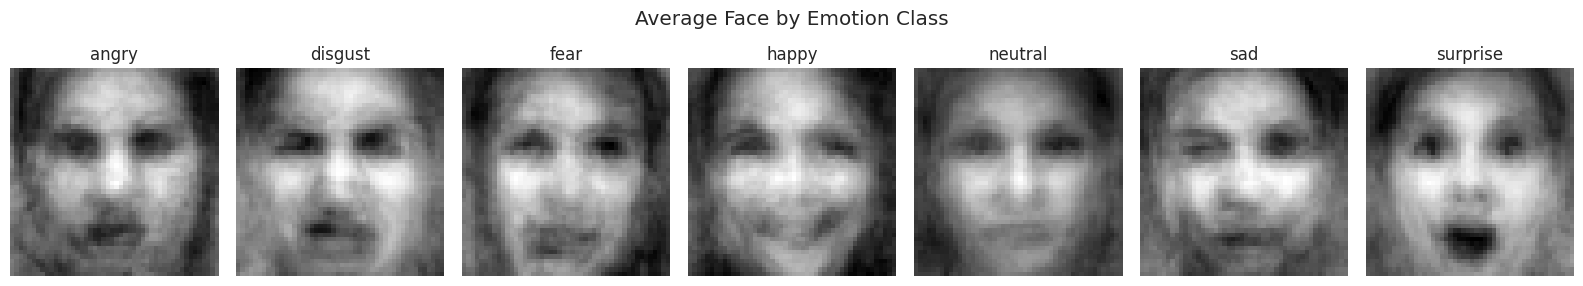

In [ ]:
# Code Cell 20: Chart 8 - Average Face By Emotion
# Average pixels show broad class patterns but are not used as model features.
# Create one average face for each class using a capped sample of training images.
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 3))
for axis, class_name in zip(axes, CLASS_NAMES):
    # Use only training images and cap the sample size so every class is treated consistently.
    class_paths = metadata_df[(metadata_df['split'] == 'train') & (metadata_df['label'] == class_name)]['file_path']
    class_paths = class_paths.sample(min(80, len(class_paths)), random_state=SEED)
    arrays = [np.asarray(Image.open(path).convert('L').resize(IMG_SIZE), dtype=np.float32) for path in class_paths]
    mean_image = np.mean(arrays, axis=0)
    axis.imshow(mean_image, cmap='gray')
    axis.set_title(class_name)
    axis.axis('off')

plt.suptitle('Average Face by Emotion Class')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Average-face charts were selected to understand the common face structure within each emotion class. They provide a simple visual summary of thousands of images.

##### 2. What is/are the insight(s) found from the chart?

The average faces show that all classes share a common face layout, but expression areas around the mouth and eyes can differ. This supports the use of convolution layers because they learn local visual patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The chart gives an interpretable reason for using CNNs. The model needs to learn subtle shape differences, not just brightness or file-size patterns.

#### Chart - 9

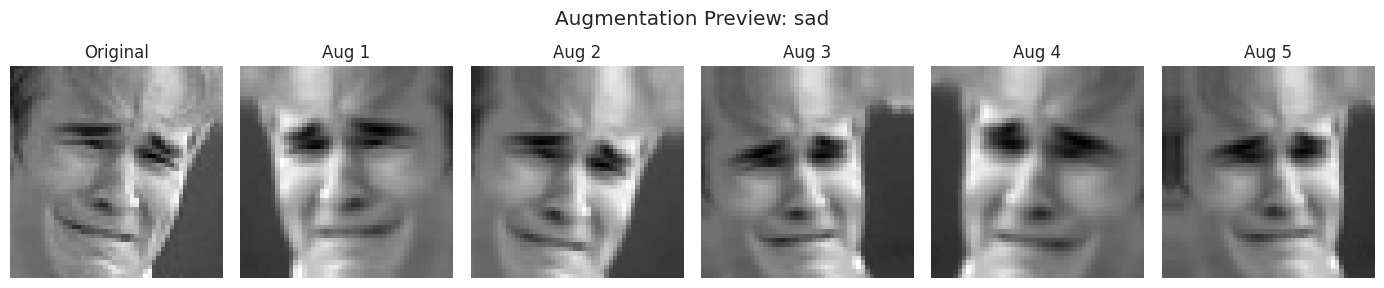

In [ ]:
# Code Cell 21: Chart 9 - Augmentation Preview
# Preview augmentation first to ensure it keeps the facial expression meaningful.
# Select one repeatable training image for an augmentation sanity check.
preview_row = metadata_df[metadata_df['split'] == 'train'].sample(1, random_state=SEED).iloc[0]
preview_image = Image.open(preview_row['file_path']).convert('L').resize(IMG_SIZE)
# Add batch and channel dimensions so the augmentation layer can process the image.
preview_tensor = tf.expand_dims(tf.convert_to_tensor(np.asarray(preview_image)[..., np.newaxis], dtype=tf.float32), axis=0)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(preview_image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Generate several random but mild variants of the same expression.
for index in range(1, 6):
    augmented = data_augmentation(preview_tensor, training=True)[0].numpy().squeeze()
    axes[index].imshow(np.clip(augmented, 0, 255), cmap='gray')
    axes[index].set_title(f'Aug {index}')
    axes[index].axis('off')

plt.suptitle(f'Augmentation Preview: {preview_row["label"]}')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The augmentation preview was selected to verify that training transformations remain realistic. Emotion labels should not change because of augmentation.

##### 2. What is/are the insight(s) found from the chart?

The output shows small flips, rotations, zooms, translations, and contrast changes. These transformations are realistic for face images and should help the model generalize to new examples.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Realistic augmentation can reduce overfitting and improve validation performance. Extreme augmentation was avoided because facial emotions are subtle.

#### Chart - 10

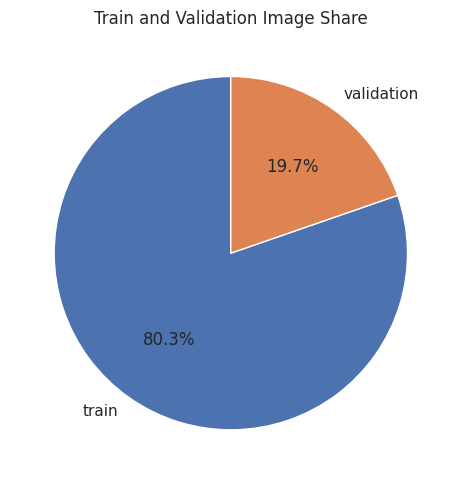

,split,total_images
0,train,28821
1,validation,7066


In [ ]:
# Code Cell 22: Chart 10 - Train Validation Share
# Show the original split share before duplicate-safe model splitting.
plt.pie(split_count_table['total_images'], labels=split_count_table['split'], autopct='%1.1f%%', startangle=90)
# Add percentages so the relative size of the original splits is visible at a glance.
plt.title('Train and Validation Image Share')
plt.tight_layout()
plt.show()

display(split_count_table)


##### 1. Why did you pick the specific chart?

The split-share chart was selected to confirm how much data is available for training and validation. This gives context for model reliability.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the training split is much larger than the official validation split. This is expected and gives the model enough images to learn while still keeping a separate validation set for checking performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The split is suitable for a capstone notebook because training has enough volume and validation has enough examples for class-wise evaluation.

#### Chart - 11

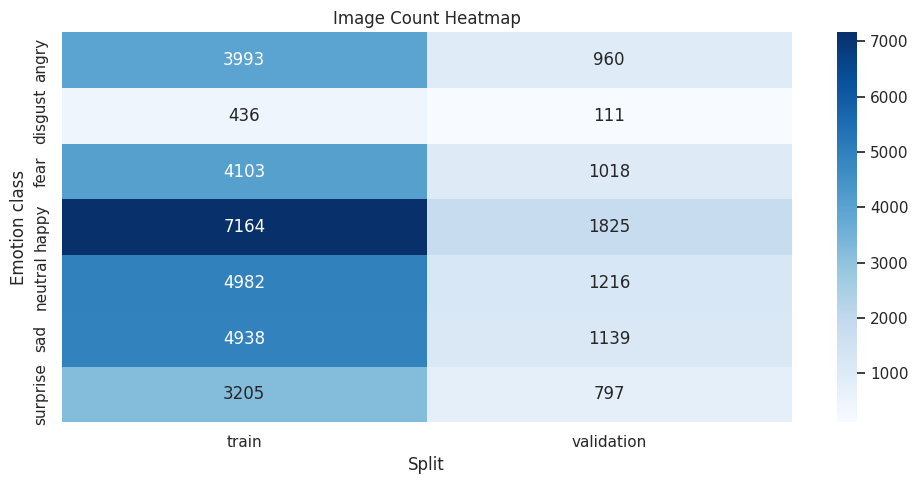

In [ ]:
# Code Cell 23: Chart 11 - Image Count Heatmap
# Reshape class counts into a split-by-emotion matrix for the heatmap.
count_matrix = class_count_table.pivot(index='label', columns='split', values='image_count').fillna(0)
# Annotate exact counts so rare classes remain visible.
sns.heatmap(count_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title('Image Count Heatmap')
plt.xlabel('Split')
plt.ylabel('Emotion class')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The heatmap was selected because it summarizes split and class counts in one compact table. It is easier to compare class coverage across splits.

##### 2. What is/are the insight(s) found from the chart?

The heatmap confirms that every emotion appears in both train and validation folders. The imbalance pattern is still visible, especially for disgust.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This output supports using the official validation folder for final comparison and checking class-wise metrics for all seven emotions.

#### Chart - 12

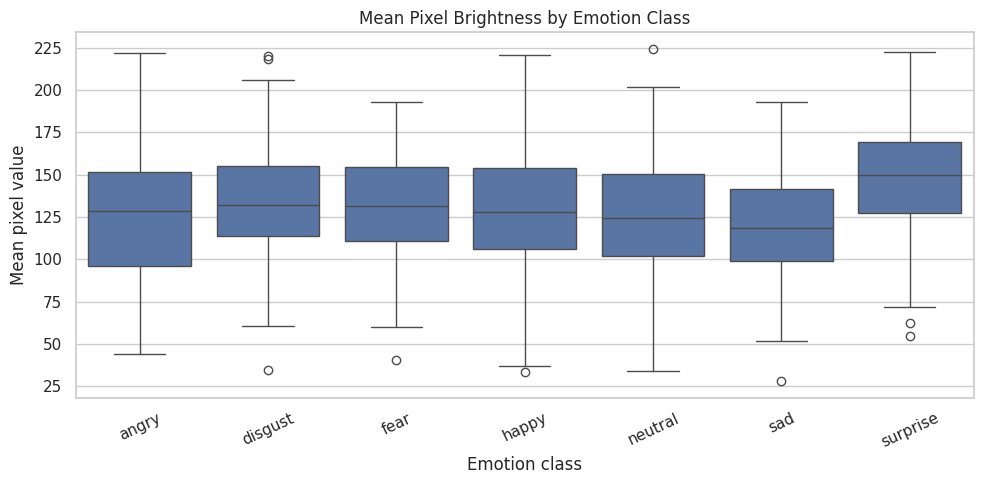

In [ ]:
# Code Cell 24: Chart 12 - Brightness By Emotion
# Compare the spread of mean pixel brightness for each emotion, not just one image.
# Use a box plot because its median and spread reveal brightness variation within each class.
sns.boxplot(data=image_profile_df, x='label', y='mean_pixel')
plt.title('Mean Pixel Brightness by Emotion Class')
plt.xlabel('Emotion class')
plt.ylabel('Mean pixel value')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The brightness boxplot was selected to check whether some emotion classes have noticeably different lighting patterns. A model should not depend only on brightness.

##### 2. What is/are the insight(s) found from the chart?

The output shows brightness variation across samples, but the classes overlap. This means brightness alone cannot separate emotions, so the model must learn facial structure and expression patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This supports normalization and mild contrast augmentation. It also warns against using simple pixel statistics as the final model features.

#### Chart - 13

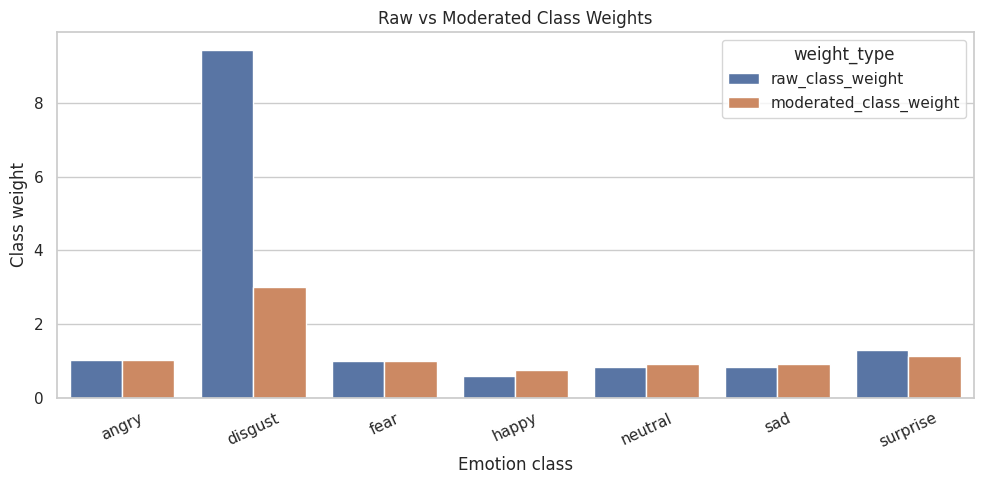

,label,raw_class_weight,moderated_class_weight
0,angry,1.031126,1.015444
1,disgust,9.443316,3.000000
2,fear,1.003482,1.001739
3,happy,0.574719,0.758102
4,neutral,0.826432,0.909083
5,sad,0.833796,0.913124
6,surprise,1.284645,1.133422


In [ ]:
# Code Cell 25: Chart 13 - Class Weight Chart
# Show diagnostic weight values without using aggressive weights in final training.
# Build a diagnostic table from the cleaned model-training class weights.
class_weight_table = pd.DataFrame({
    'label': [index_to_class[index] for index in sorted(class_weight_dict)],
    'raw_class_weight': [raw_class_weight_dict[index] for index in sorted(raw_class_weight_dict)],
    'moderated_class_weight': [class_weight_dict[index] for index in sorted(class_weight_dict)]
})

# Reshape both weight columns so they can be compared in one chart.
plot_weight_table = class_weight_table.melt(
    id_vars='label',
    value_vars=['raw_class_weight', 'moderated_class_weight'],
    var_name='weight_type',
    value_name='class_weight'
)

# Plot raw and moderated weights for diagnosis; the final CNN does not use them directly.
sns.barplot(data=plot_weight_table, x='label', y='class_weight', hue='weight_type')
plt.title('Raw vs Moderated Class Weights')
plt.xlabel('Emotion class')
plt.ylabel('Class weight')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

display(class_weight_table)


##### 1. Why did you pick the specific chart?

The class-weight chart was selected because the previous model output showed weak balanced performance. Raw weights can be too aggressive for the small disgust class, so moderated weights are shown as the safer training choice.

##### 2. What is/are the insight(s) found from the chart?

The output shows that the raw disgust weight is very high. The moderated weight reduces that pressure, which helps avoid unstable training where the model overcorrects toward minority classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. This insight directly improves the modeling plan. Macro F1 and class-wise results keep minority-class performance visible, while the final CNN avoids aggressive class weights because earlier weighted training was unstable.

#### Chart - 14 - Correlation Heatmap

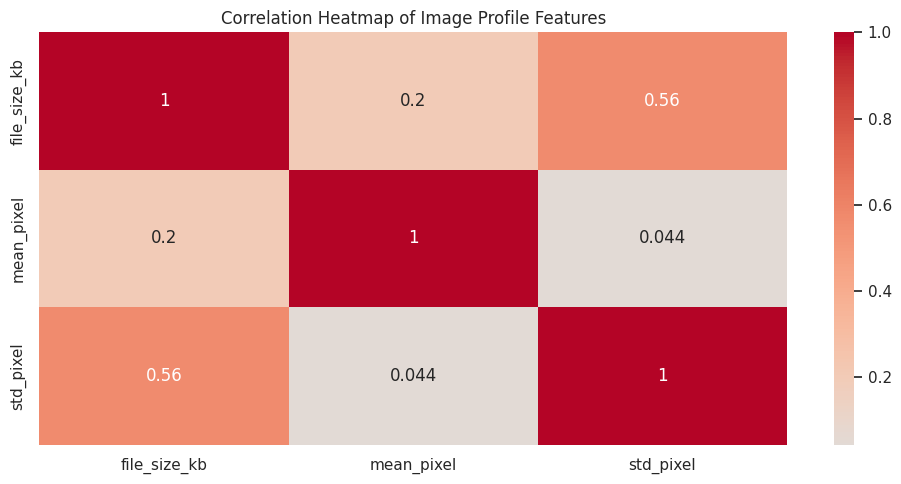

In [ ]:
# Code Cell 26: Chart 14 - Correlation Heatmap
# Keep only varying numeric image-profile fields before calculating correlations.
numeric_profile = image_profile_df[['width', 'height', 'file_size_kb', 'mean_pixel', 'std_pixel']].copy()
numeric_profile = numeric_profile.loc[:, numeric_profile.nunique() > 1]

# Skip the chart when there are not enough changing numeric features.
if numeric_profile.shape[1] >= 2:
    # Plot correlations to check whether simple file and pixel statistics move together.
    sns.heatmap(numeric_profile.corr(), annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Image Profile Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough variable numeric columns for a useful correlation heatmap.')


##### 1. Why did you pick the specific chart?

The correlation heatmap was selected to check relationships among simple image-profile features. These features are used for EDA, not as final model inputs.

##### 2. What is/are the insight(s) found from the chart?

The heatmap mainly explains relationships between brightness, contrast, file size, and image dimensions. The overlap in these simple features confirms that CNN feature learning is needed.

#### Chart - 15 - Pair Plot

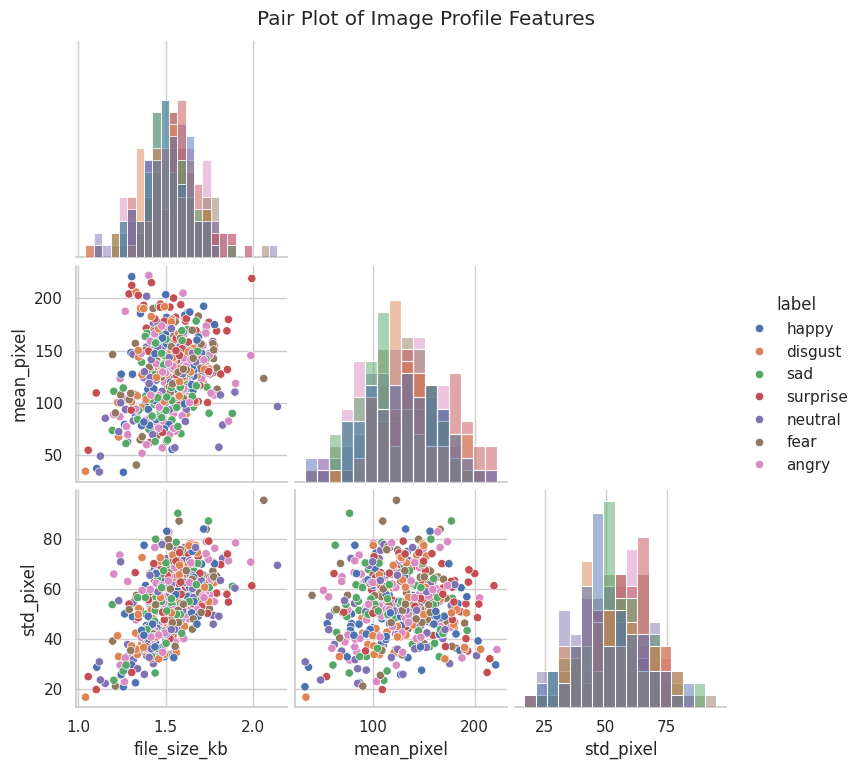

In [ ]:
# Code Cell 27: Chart 15 - Pair Plot
# Limit the pair plot to useful sampled image-profile features.
pairplot_columns = ['file_size_kb', 'mean_pixel', 'std_pixel', 'label']
pairplot_df = image_profile_df[pairplot_columns].sample(min(500, len(image_profile_df)), random_state=SEED)

# Colour points by emotion to check whether these simple statistics separate classes.
sns.pairplot(pairplot_df, hue='label', diag_kind='hist', corner=True)
plt.suptitle('Pair Plot of Image Profile Features', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

The pair plot was selected to visually check whether simple image-profile features separate emotion classes. If classes overlap heavily, manual numeric rules will not be enough.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows heavy overlap between classes. This confirms that emotion recognition needs learned visual features from CNN or transfer learning models rather than simple metadata features.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Three practical hypotheses are tested using the image metadata and sampled image profile features. These tests are used only for dataset understanding. The final prediction model is still based on CNN image learning, not on these simple statistical tests.


### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The training images are evenly distributed across all seven emotion classes.

Alternate hypothesis: The training images are not evenly distributed across all seven emotion classes.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 28: Hypothesis Test 1 - Class Balance
# Chi-square goodness-of-fit test for training class balance.
# Use observed training counts as the input to the class-balance test.
train_counts_for_test = train_class_counts.sort_values('label')['image_count'].to_numpy()
# Create equal expected counts for the null hypothesis of balanced classes.
expected_counts = np.repeat(train_counts_for_test.sum() / len(train_counts_for_test), len(train_counts_for_test))
# Run the chi-square goodness-of-fit test.
chi2_stat, p_value_class_balance = stats.chisquare(f_obs=train_counts_for_test, f_exp=expected_counts)

print('Chi-square statistic:', round(chi2_stat, 4))
print('P-value:', p_value_class_balance)


Chi-square statistic: 6097.1118
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

The chi-square goodness-of-fit test was used. It checks whether the observed class counts are close to an equal distribution across all seven emotions.

##### Why did you choose the specific statistical test?

This test is suitable because the hypothesis is about frequency counts across multiple emotion categories. It helps confirm whether class imbalance is statistically meaningful.


### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The emotion distribution is similar in the train and validation splits.

Alternate hypothesis: The emotion distribution is different between the train and validation splits.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 29: Hypothesis Test 2 - Split Distribution
# Chi-square test of independence for split and emotion class.
# Build a contingency table of split and emotion labels.
split_label_matrix = pd.crosstab(metadata_df['split'], metadata_df['label'])
# Test whether the original split distribution differs by emotion.
chi2_stat_split, p_value_split_distribution, dof_split, expected_split = stats.chi2_contingency(split_label_matrix)

print('Chi-square statistic:', round(chi2_stat_split, 4))
print('Degrees of freedom:', dof_split)
print('P-value:', p_value_split_distribution)
display(split_label_matrix)


Chi-square statistic: 6.267
Degrees of freedom: 6
P-value: 0.3939570844288941


label,angry,disgust,fear,happy,neutral,sad,surprise
split,,,,,,,
train,3993,436,4103,7164,4982,4938,3205
validation,960,111,1018,1825,1216,1139,797


##### Which statistical test have you done to obtain P-Value?

The chi-square test of independence was used. It checks whether the split name and emotion label are related as categorical variables.

##### Why did you choose the specific statistical test?

This test is suitable because both variables are categorical. It helps check whether the validation split follows a similar class pattern to the training split.


### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null hypothesis: The sampled happy and sad images have the same average brightness.

Alternate hypothesis: The sampled happy and sad images have different average brightness.


#### 2. Perform an appropriate statistical test.

In [ ]:
# Code Cell 30: Hypothesis Test 3 - Brightness Difference
# Compare brightness as an image property, not as a replacement for learned features.
# Welch's t-test for brightness difference between happy and sad samples.
# Extract sampled brightness values for the two emotions being compared.
happy_brightness = image_profile_df[image_profile_df['label'] == 'happy']['mean_pixel']
sad_brightness = image_profile_df[image_profile_df['label'] == 'sad']['mean_pixel']

# Use Welch's t-test because the two groups may not have equal variance.
t_stat_brightness, p_value_brightness = stats.ttest_ind(
    happy_brightness,
    sad_brightness,
    equal_var=False
)

print('T-statistic:', round(t_stat_brightness, 4))
print('P-value:', p_value_brightness)
print('Happy mean brightness:', round(happy_brightness.mean(), 2))
print('Sad mean brightness:', round(sad_brightness.mean(), 2))


T-statistic: 2.2755
P-value: 0.023543652645671483
Happy mean brightness: 129.33
Sad mean brightness: 120.84


##### Which statistical test have you done to obtain P-Value?

Welch's t-test was used. It compares the average brightness of two groups without assuming equal variance between the groups.

##### Why did you choose the specific statistical test?

This test is suitable because the comparison is between two numeric brightness samples. It helps check whether simple lighting differences exist between two emotion classes.


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Code Cell 31: Missing And Invalid Data Summary
# Report missing or invalid image issues found during data integrity checks.
# Collect label, path, and readability issues in one table.
missing_value_summary = pd.DataFrame({
    'issue': ['missing_label', 'missing_file_path', 'unreadable_image'],
    'count': [
        int(metadata_df['label'].isna().sum()),
        int(metadata_df['file_path'].isna().sum()),
        invalid_image_count
    ]
})

display(missing_value_summary)


,issue,count
0,missing_label,0
1,missing_file_path,0
2,unreadable_image,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

No numeric missing-value imputation was required because this is an image-folder dataset, not a tabular dataset. Labels come from folder names, and unreadable image files were checked separately. If unreadable files are found, they should be reviewed or removed from the training folder before final training.


### 2. Handling Outliers

In [ ]:
# Code Cell 32: Brightness Outlier Check
# Keep valid dark images because a brightness outlier is not necessarily a bad image.
# Identify brightness outliers from sampled image profiles using the IQR rule.
# Calculate IQR limits from sampled brightness values without deleting valid dark images.
q1 = image_profile_df['mean_pixel'].quantile(0.25)
q3 = image_profile_df['mean_pixel'].quantile(0.75)
iqr = q3 - q1
lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# List only extreme sampled values so they can be inspected manually.
brightness_outliers = image_profile_df[
    (image_profile_df['mean_pixel'] < lower_limit) |
    (image_profile_df['mean_pixel'] > upper_limit)
]

print('Brightness outlier count in sampled profiles:', len(brightness_outliers))
display(brightness_outliers[['split', 'label', 'mean_pixel', 'file_path']].head())


Brightness outlier count in sampled profiles: 4


,split,label,mean_pixel,file_path
158,train,disgust,34.610245,/content/deepfer_dataset/images/images/train/d...
275,train,happy,33.641060,/content/deepfer_dataset/images/images/train/h...
905,validation,neutral,33.877171,/content/deepfer_dataset/images/images/validat...
1008,validation,sad,28.143229,/content/deepfer_dataset/images/images/validat...


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were checked using image brightness on a sampled profile table. Images were not removed automatically because very dark or bright images can still represent real-world conditions. Normalization and contrast augmentation are safer choices for this project than deleting valid face images.

### 3. Categorical Encoding

In [ ]:
# Code Cell 33: Encode Emotion Labels
# Encode emotion labels as integer class IDs for model training.
# Keep the class-ID order visible for model outputs and confusion matrices.
label_mapping_df = pd.DataFrame({
    'class_id': list(index_to_class.keys()),
    'emotion_label': list(index_to_class.values())
})

display(label_mapping_df)


,class_id,emotion_label
0,0,angry
1,1,disgust
2,2,fear
3,3,happy
4,4,neutral
5,5,sad
6,6,surprise


#### What all categorical encoding techniques have you used & why did you use those techniques?

The emotion folders are categorical labels. TensorFlow encodes these labels into integer class IDs while loading the image folders. This is suitable because the model uses sparse categorical cross-entropy, which expects integer labels for multi-class classification.


### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Code Cell 34: Text Step Not Applicable - Expand Contraction
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 2. Lower Casing

In [ ]:
# Code Cell 35: Text Step Not Applicable - Lower Casing
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 3. Removing Punctuations

In [ ]:
# Code Cell 36: Text Step Not Applicable - Remove Punctuation
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Code Cell 37: Text Step Not Applicable - Remove URLs
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Code Cell 38: Text Step Not Applicable - Remove Stopwords
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


In [ ]:
# Code Cell 39: Text Step Not Applicable - Remove White Spaces
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 6. Rephrase Text

In [ ]:
# Code Cell 40: Text Step Not Applicable - Rephrase Text
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 7. Tokenization

In [ ]:
# Code Cell 41: Text Step Not Applicable - Tokenization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 8. Text Normalization

In [ ]:
# Code Cell 42: Text Step Not Applicable - Text Normalization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


##### Which text normalization technique have you used and why?

Text normalization was not used because the dataset contains images, not text. Adding NLP preprocessing here would not be meaningful for facial emotion recognition.


#### 9. Part of speech tagging

In [ ]:
# Code Cell 43: Text Step Not Applicable - POS Tagging
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


#### 10. Text Vectorization

In [ ]:
# Code Cell 44: Text Step Not Applicable - Text Vectorization
# Text preprocessing is not required for this image classification dataset.
print('Not applicable: the dataset contains face images, not text data.')


Not applicable: the dataset contains face images, not text data.


##### Which text vectorization technique have you used and why?

Text vectorization was not used because there are no text fields in the dataset. The image tensors are the model inputs.


### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Code Cell 45: Image Feature Preparation Plan
# This project uses image tensors, so text-vector feature preparation does not apply.
# Document the image-specific preparation steps used instead of text preprocessing.
feature_preparation = pd.DataFrame({
    'step': ['resize', 'grayscale channel', 'normalization', 'augmentation', 'cnn filters'],
    'purpose': [
        'make every image shape consistent',
        'match the dataset format and keep training light',
        'scale pixel values for stable model training',
        'create small realistic image variations',
        'learn visual patterns automatically'
    ]
})

display(feature_preparation)


,step,purpose
0,resize,make every image shape consistent
1,grayscale channel,match the dataset format and keep training light
2,normalization,scale pixel values for stable model training
3,augmentation,create small realistic image variations
4,cnn filters,learn visual patterns automatically


#### 2. Feature Selection

In [ ]:
# Code Cell 46: Feature Selection Note
# CNN models learn visual features directly, so manual feature selection is not applied.
print('Manual feature selection is not applied because CNN layers learn useful image features during training.')


Manual feature selection is not applied because CNN layers learn useful image features during training.


##### What all feature selection methods have you used  and why?

Manual feature selection was not used. In deep learning image classification, convolution layers learn features such as edges, curves, mouth shape, eye shape, and expression patterns automatically.


##### Which all features you found important and why?

The important learned features are expected to come from facial regions such as eyes, eyebrows, cheeks, and mouth. These areas usually carry strong emotion signals. The notebook later uses occlusion sensitivity to show which image regions influenced a prediction.


### 5. Data Transformation

Yes. Images need transformation before model training. The main transformations are resizing to a fixed shape and converting image files into numeric tensors. Augmentation is also used during training to improve generalization.


In [ ]:
# Code Cell 47: Create Normalization Layer
# Create a normalization layer for CNN models.
normalization_layer = layers.Rescaling(1.0 / 255, name='rescale_pixels')

print('Image transformation plan: resize to', IMG_SIZE, 'and scale pixel values to the 0-1 range.')


Image transformation plan: resize to (48, 48) and scale pixel values to the 0-1 range.


### 6. Data Scaling

In [ ]:
# Code Cell 48: Demonstrate Pixel Scaling
# Demonstrate pixel scaling on a small sample image.
sample_arr = np.asarray(preview_image, dtype=np.float32)
# Divide pixel values by 255 to demonstrate the same scaling used by the custom CNN.
scaled_sample_arr = sample_arr / 255.0

print('Original pixel range:', sample_arr.min(), 'to', sample_arr.max())
print('Scaled pixel range:', round(float(scaled_sample_arr.min()), 4), 'to', round(float(scaled_sample_arr.max()), 4))


Original pixel range: 5.0 to 175.0
Scaled pixel range: 0.0196 to 0.6863


Pixel scaling with Rescaling(1./255) was used. It converts pixel values from the 0-255 range to the 0-1 range. This helps neural networks train more smoothly because the input values become smaller and consistent.


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction is not done using PCA because the project uses CNNs. CNN pooling layers reduce spatial dimensions naturally while keeping useful visual patterns. This is more suitable for images than flattening pixels and applying a tabular reduction method.


In [ ]:
# Code Cell 49: Dimensionality Reduction Note
# CNN pooling layers will reduce image dimensions during model training.
print('Dimensionality reduction will happen inside CNN MaxPooling layers, not through PCA.')


Dimensionality reduction will happen inside CNN MaxPooling layers, not through PCA.


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No separate dimensionality reduction technique was used. MaxPooling inside the CNN is enough for this image classification workflow.


### 8. Data Splitting

In [ ]:
# Code Cell 50: Create Duplicate-Safe Train, Tuning, And Test Arrays
# Start from files that passed the readability and extension checks.
clean_metadata_df = metadata_df[
    metadata_df['is_readable'] & metadata_df['extension'].isin(supported_extensions)
].copy()
clean_metadata_df['label_id'] = clean_metadata_df['label'].map(class_to_index).astype('int32')

# Remove hashes with conflicting labels because one image cannot safely train two emotions.
hash_label_count = clean_metadata_df.groupby('file_hash')['label'].nunique()
conflicting_hashes = set(hash_label_count[hash_label_count > 1].index)
non_conflict_df = clean_metadata_df[~clean_metadata_df['file_hash'].isin(conflicting_hashes)].copy()

# Deduplicate each original folder first. The official validation folder is then
# stripped of every hash already present in the training pool.
train_pool_file_df = (
    non_conflict_df[non_conflict_df['split'] == 'train']
    .sort_values(['label', 'file_name'])
    .drop_duplicates(subset=['file_hash'], keep='first')
    .copy()
)
official_test_file_df = (
    non_conflict_df[non_conflict_df['split'] == 'validation']
    .sort_values(['label', 'file_name'])
    .drop_duplicates(subset=['file_hash'], keep='first')
    .copy()
)
train_pool_hashes = set(train_pool_file_df['file_hash'])
test_file_df = official_test_file_df[
    ~official_test_file_df['file_hash'].isin(train_pool_hashes)
].copy()

# Split only the cleaned training pool. This tuning split is used for callbacks and
# model selection; the duplicate-safe official validation folder is reserved for held-out final evaluation.
train_file_df, tuning_file_df = train_test_split(
    train_pool_file_df,
    test_size=0.10,
    stratify=train_pool_file_df['label_id'],
    random_state=SEED,
)
train_file_df = train_file_df.sort_values(['label', 'file_name']).reset_index(drop=True)
tuning_file_df = tuning_file_df.sort_values(['label', 'file_name']).reset_index(drop=True)
test_file_df = test_file_df.sort_values(['label', 'file_name']).reset_index(drop=True)

# Check every split pair before loading images so exact duplicates cannot leak across them.
train_hashes = set(train_file_df['file_hash'])
tuning_hashes = set(tuning_file_df['file_hash'])
test_hashes = set(test_file_df['file_hash'])
if train_hashes & tuning_hashes or train_hashes & test_hashes or tuning_hashes & test_hashes:
    raise ValueError('Exact duplicate hash overlap was found between model splits.')

# Fit imbalance diagnostics only on the model-training portion, not on tuning/test.
clean_train_labels = train_file_df['label_id'].to_numpy()
clean_raw_class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_NAMES)),
    y=clean_train_labels,
)
raw_class_weight_dict = {
    index: float(weight)
    for index, weight in enumerate(clean_raw_class_weight_values)
}
class_weight_dict = {
    index: float(min(np.sqrt(weight), 3.0))
    for index, weight in raw_class_weight_dict.items()
}

# Record the cleaned split sizes so the final run can be checked later.
split_summary = pd.DataFrame({
    'split': [
        'original_train',
        'deduplicated_training_pool',
        'model_training',
        'tuning_validation',
        'untouched_final_test',
        'conflicting_hashes_removed',
    ],
    'image_count': [
        int((clean_metadata_df['split'] == 'train').sum()),
        len(train_pool_file_df),
        len(train_file_df),
        len(tuning_file_df),
        len(test_file_df),
        len(conflicting_hashes),
    ],
})
display(split_summary)

model_split_count_table = pd.DataFrame({
    'model_training': train_file_df['label'].value_counts(),
    'tuning_validation': tuning_file_df['label'].value_counts(),
    'untouched_final_test': test_file_df['label'].value_counts(),
}).fillna(0).astype(int).reindex(CLASS_NAMES)
display(model_split_count_table)

# Load pixels only after the file-level split is fixed.
def load_grayscale_image_arrays(file_df, image_size):
    image_arrays = []
    label_ids = []
    for row in file_df.itertuples(index=False):
        with Image.open(row.file_path).convert('L') as image:
            image = image.resize(image_size)
            image_array = np.asarray(image, dtype=np.float32) / 255.0
        image_arrays.append(image_array)
        label_ids.append(int(row.label_id))
    images = np.expand_dims(np.stack(image_arrays), axis=-1).astype('float32')
    labels = np.asarray(label_ids, dtype='int32')
    return images, labels

# Create separate NumPy arrays for training, tuning, and final evaluation.
X_train, y_train = load_grayscale_image_arrays(train_file_df, IMG_SIZE)
X_tuning, y_tuning = load_grayscale_image_arrays(tuning_file_df, IMG_SIZE)
X_test, y_test = load_grayscale_image_arrays(test_file_df, IMG_SIZE)
y_train_categorical = tf.keras.utils.to_categorical(y_train, num_classes=len(CLASS_NAMES))
y_tuning_categorical = tf.keras.utils.to_categorical(y_tuning, num_classes=len(CLASS_NAMES))

# Batch each already-separated array without applying preprocessing learned from tuning or test data.
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(4000, seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE)
tuning_ds = tf.data.Dataset.from_tensor_slices((X_tuning, y_tuning)).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

print('Duplicate-safe train, tuning, and untouched test arrays are ready.')
print('Train shape:', X_train.shape)
print('Tuning shape:', X_tuning.shape)
print('Untouched test shape:', X_test.shape)
print('Exact hash overlap:', {'train_tuning': len(train_hashes & tuning_hashes), 'train_test': len(train_hashes & test_hashes), 'tuning_test': len(tuning_hashes & test_hashes)})


,split,image_count
0,original_train,28821
1,deduplicated_training_pool,27503
2,model_training,24752
3,tuning_validation,2751
4,untouched_final_test,6474
5,conflicting_hashes_removed,57


,model_training,tuning_validation,untouched_final_test
label,,,
angry,3442,382,893
disgust,338,38,82
fear,3499,389,914
happy,6338,704,1752
neutral,4377,487,1182
sad,4346,483,1083
surprise,2412,268,568


Duplicate-safe train, tuning, and untouched test arrays are ready.
Train shape: (24752, 48, 48, 1)
Tuning shape: (2751, 48, 48, 1)
Untouched test shape: (6474, 48, 48, 1)
Exact hash overlap: {'train_tuning': 0, 'train_test': 0, 'tuning_test': 0}


##### What data splitting ratio have you used and why?

The original dataset already has official train and validation folders. The notebook keeps this structure, then removes duplicate leakage before modeling. Training uses the cleaned train files, while validation uses cleaned validation files that are not exact duplicates of training images. This makes the evaluation more honest and still follows the dataset structure provided for the project.


### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is imbalanced. Some emotion classes have many more images than others, especially happy compared with disgust. This can make the model biased toward majority classes if only accuracy is used.


In [ ]:
# Code Cell 51: Show Class Weights
# Display clean class weights as a diagnostic for imbalance.
class_weight_table = pd.DataFrame({
    'class_id': list(class_weight_dict.keys()),
    'label': [index_to_class[index] for index in class_weight_dict.keys()],
    'clean_raw_weight': [raw_class_weight_dict[index] for index in class_weight_dict.keys()],
    'clean_moderated_weight': list(class_weight_dict.values())
})

# The final CNN does not use these weights directly because the latest run showed unstable validation scores with aggressive weighting.
display(class_weight_table)
print('Final CNN imbalance strategy: use clean data, augmentation, macro F1-score, and confusion-matrix checks without aggressive class weights.')


,class_id,label,clean_raw_weight,clean_moderated_weight
0,0,angry,1.027310,1.013563
1,1,disgust,10.461538,3.000000
2,2,fear,1.010574,1.005273
3,3,happy,0.557905,0.746930
4,4,neutral,0.807859,0.898810
5,5,sad,0.813622,0.902010
6,6,surprise,1.466003,1.210786


Final CNN imbalance strategy: use clean data, augmentation, macro F1-score, and confusion-matrix checks without aggressive class weights.


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Class weights were recomputed after duplicate-safe cleaning to understand imbalance clearly. The final CNN does not force these weights during training because the previous weighted run became unstable. Instead, the final model handles imbalance through clean duplicate-safe data, realistic augmentation, macro F1-score monitoring, confusion-matrix review, and class-wise recall checks.


## Evaluation Approach

I used three separate roles for the data. The model-training split was used to learn the weights, the tuning-validation split was used for callbacks and model comparison, and the held-out final set was used after model selection.

The reference-style FER CNN achieved the best tuning result, with 0.654 accuracy and 0.625 macro F1-score. The baseline CNN reached 0.495 accuracy and 0.411 macro F1, while EfficientNetB0 reached 0.324 accuracy and 0.248 macro F1. Based on this comparison, I selected the reference-style FER CNN for the final evaluation.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# Code Cell 52: Train Baseline CNN
# These dictionaries keep model scores, reports, matrices, histories, and trained models in one place.
model_results = {}
benchmark_results = {}
trained_models = {}
model_histories = {}
classification_reports = {}
confusion_matrices = {}
prediction_distributions = {}

def plot_training_history(history, title):
    # Convert Keras training history into a dataframe for easy plotting.
    history_df = pd.DataFrame(history.history)

    # Plot accuracy and loss side by side to check learning and overfitting.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history_df[['accuracy', 'val_accuracy']].plot(ax=axes[0])
    axes[0].set_title(f'{title} Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')

    history_df[['loss', 'val_loss']].plot(ax=axes[1])
    axes[1].set_title(f'{title} Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

def explain_model_output(model_name, scores, report_df, prediction_distribution):
    # Focus the explanation on class-wise rows, not summary rows.
    class_report = report_df.loc[CLASS_NAMES]
    best_class = class_report['f1-score'].idxmax()
    weakest_class = class_report['f1-score'].idxmin()
    missing_prediction_classes = prediction_distribution[prediction_distribution['predicted_count'] == 0]['label'].tolist()
    top_prediction_share = prediction_distribution['prediction_share'].max()
    top_prediction_class = prediction_distribution.sort_values('prediction_share', ascending=False).iloc[0]['label']

    print(f'{model_name} output interpretation on {scores["dataset"]}:')
    print(f"- Accuracy is {scores['accuracy']:.3f}, and macro F1-score is {scores['macro_f1']:.3f}.")
    print(f'- Best handled emotion by F1-score: {best_class}.')
    print(f'- Weakest handled emotion by F1-score: {weakest_class}.')

    if missing_prediction_classes:
        print('- Classes with zero predictions:', ', '.join(missing_prediction_classes))
    else:
        print('- The model predicted at least one sample for every emotion class.')

    if top_prediction_share > 0.60:
        print(f'- Warning: predictions are concentrated in {top_prediction_class}, which shows class collapse.')
    else:
        print('- Prediction distribution is not dominated by one class.')

    print('- Macro F1 is important here because it treats every emotion class equally.')

def collect_predictions(model, data, labels=None):
    # Support both NumPy arrays and tf.data datasets in the same evaluation helper.
    y_true = []
    y_pred = []

    if isinstance(data, tf.data.Dataset):
        for batch_images, batch_labels in data:
            probabilities = model.predict(batch_images, verbose=0)
            predictions = np.argmax(probabilities, axis=1)
            label_array = batch_labels.numpy()
            if label_array.ndim > 1:
                label_array = np.argmax(label_array, axis=1)
            y_true.extend(label_array.astype('int32').tolist())
            y_pred.extend(predictions.tolist())
    else:
        probabilities = model.predict(data, batch_size=BATCH_SIZE, verbose=0)
        predictions = np.argmax(probabilities, axis=1)
        label_array = labels
        if label_array.ndim > 1:
            label_array = np.argmax(label_array, axis=1)
        y_true = label_array.astype('int32').tolist()
        y_pred = predictions.tolist()

    return y_true, y_pred

def evaluate_model(model, data, labels, model_name, class_names, dataset_name='evaluation', store_result=True):
    # Store true labels and predicted labels from the selected evaluation data.
    y_true, y_pred = collect_predictions(model, data, labels)

    # Pass all label IDs explicitly so reports stay stable even if one class is predicted rarely.
    all_label_ids = list(range(len(class_names)))
    report = classification_report(
        y_true,
        y_pred,
        labels=all_label_ids,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T

    # Keep confusion matrix shape fixed at 7x7 for all emotion classes.
    matrix = confusion_matrix(y_true, y_pred, labels=all_label_ids)

    # Prediction distribution shows whether the model is overusing one emotion class.
    prediction_distribution = pd.DataFrame({
        'label': class_names,
        'predicted_count': [int(np.sum(np.array(y_pred) == label_id)) for label_id in all_label_ids]
    })
    prediction_distribution['prediction_share'] = prediction_distribution['predicted_count'] / max(len(y_pred), 1)

    # Macro scores are important because this dataset is imbalanced.
    scores = {
        'model': model_name,
        'dataset': dataset_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'macro_f1': report['macro avg']['f1-score'],
        'weighted_f1': report['weighted avg']['f1-score']
    }

    # Store evaluation outputs with their explicit split name.
    result_key = f'{model_name}_{dataset_name}'
    classification_reports[result_key] = report_df
    confusion_matrices[result_key] = matrix
    prediction_distributions[result_key] = prediction_distribution

    if store_result:
        model_results[model_name] = scores
        trained_models[model_name] = model
    else:
        benchmark_results[result_key] = scores

    explain_model_output(model_name, scores, report_df, prediction_distribution)
    display(prediction_distribution)

    return scores, report_df, matrix

def build_baseline_cnn(input_shape, num_classes):
    # Start with a compact CNN so the project has a simple baseline model.
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # First convolution block learns edges and small facial patterns.
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Second convolution block learns stronger local expression features.
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(),

        # Flatten keeps more spatial detail than global average pooling for this baseline.
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')
    return model

# Clear old TensorFlow graphs before building the baseline model.
tf.keras.backend.clear_session()

# Build the baseline model with one grayscale channel and seven emotion outputs.
baseline_model = build_baseline_cnn((IMG_SIZE[0], IMG_SIZE[1], 1), len(CLASS_NAMES))

# Categorical cross-entropy is used because labels are one-hot encoded for NumPy training.
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

print('Baseline CNN summary:')
baseline_model.summary()

# Train the baseline without augmentation so it remains a clean comparison point.
baseline_history = baseline_model.fit(
    X_train,
    y_train_categorical,
    validation_data=(X_tuning, y_tuning_categorical),
    epochs=BASELINE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# Evaluate the baseline on tuning validation for model comparison.
model_histories['baseline_cnn'] = baseline_history
baseline_scores, baseline_report, baseline_cm = evaluate_model(
    baseline_model,
    X_tuning,
    y_tuning,
    'baseline_cnn',
    CLASS_NAMES,
    dataset_name='tuning_validation'
)

display(pd.DataFrame([baseline_scores]))
display(baseline_report)


Baseline CNN summary:


Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.3262 - loss: 1.6890 - macro_f1: 0.2209 - val_accuracy: 0.3871 - val_loss: 1.5728 - val_macro_f1: 0.2754
Epoch 2/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4097 - loss: 1.5258 - macro_f1: 0.3127 - val_accuracy: 0.4406 - val_loss: 1.4408 - val_macro_f1: 0.3391
Epoch 3/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4499 - loss: 1.4310 - macro_f1: 0.3558 - val_accuracy: 0.4544 - val_loss: 1.4014 - val_macro_f1: 0.3551
Epoch 4/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4756 - loss: 1.3597 - macro_f1: 0.3841 - val_accuracy: 0.4693 - val_loss: 1.3679 - val_macro_f1: 0.3723
Epoch 5/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5021 - loss: 1.2976 - macro_f1: 0.4103 - val_accuracy: 0.4820 - val_loss: 1.3370 - val_macro_f1: 0.3877
Epoch 6/8
194/194 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5272 - loss: 1.2394 - macro_f1: 0.4361 - val_accuracy: 0.4925 - val_loss: 1.3262 - 

,label,predicted_count,prediction_share
0,angry,421,0.153035
1,disgust,4,0.001454
2,fear,318,0.115594
3,happy,796,0.289349
4,neutral,591,0.214831
5,sad,282,0.102508
6,surprise,339,0.123228


,model,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,baseline_cnn,tuning_validation,0.495093,0.437365,0.422597,0.410969,0.479664


,precision,recall,f1-score,support
angry,0.396675,0.437173,0.415940,382.000000
disgust,0.250000,0.026316,0.047619,38.000000
fear,0.374214,0.305913,0.336634,389.000000
happy,0.657035,0.742898,0.697333,704.000000
neutral,0.423012,0.513347,0.463822,487.000000
sad,0.414894,0.242236,0.305882,483.000000
surprise,0.545723,0.690299,0.609555,268.000000
accuracy,0.495093,0.495093,0.495093,0.495093
macro avg,0.437365,0.422597,0.410969,2751.000000
weighted avg,0.480482,0.495093,0.479664,2751.000000


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

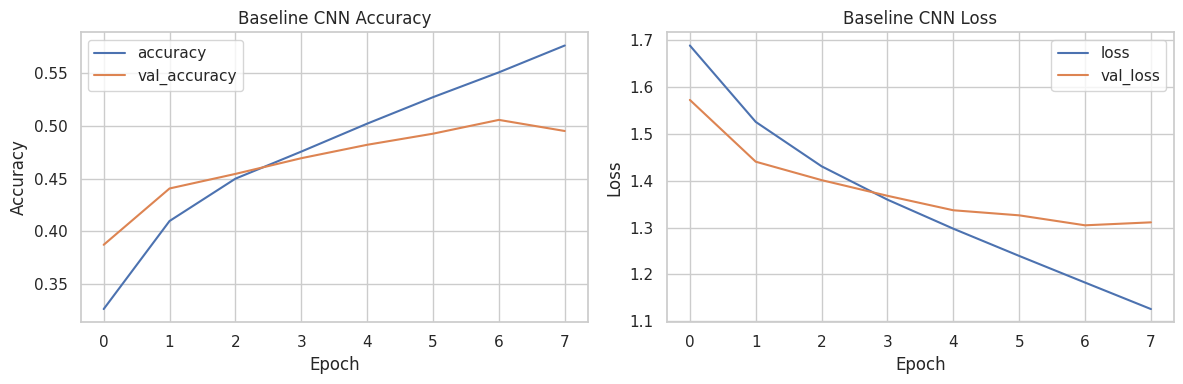

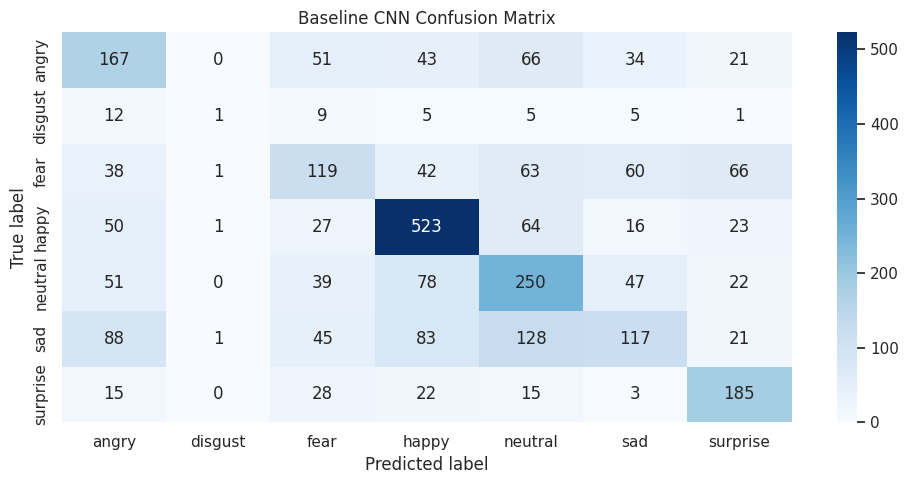

In [ ]:
# Code Cell 53: Evaluate Baseline CNN Visually
# Visualize baseline CNN training and confusion matrix.
# Plot baseline learning curves before comparing its class-level errors.
plot_training_history(baseline_history, 'Baseline CNN')

# Show which emotion pairs the baseline model confuses most often.
sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Baseline CNN Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# Code Cell 54: Record Baseline Settings
# Record the baseline settings used before tuned training.
# Keep baseline settings in one table so later model improvements can be compared fairly.
baseline_settings = pd.DataFrame({
    'setting': ['image_size', 'batch_size', 'epochs', 'optimizer', 'class_weights', 'augmentation'],
    'value': [str(IMG_SIZE), BATCH_SIZE, BASELINE_EPOCHS, 'Adam default', 'No', 'No']
})

display(baseline_settings)


,setting,value
0,image_size,"(48, 48)"
1,batch_size,128
2,epochs,8
3,optimizer,Adam default
4,class_weights,No
5,augmentation,No


##### Which hyperparameter optimization technique have you used and why?

The baseline CNN is a simple comparison model. In the completed run, it achieved 0.495 accuracy and 0.411 macro F1 on tuning validation. Its report and confusion matrix show the class-level weaknesses. It was not selected because the reference CNN had higher tuning macro F1.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, the baseline improved over random prediction and gave a useful benchmark. Its tuning accuracy was 49.5%, while macro F1-score was 0.411. However, the class-wise report shows uneven performance across emotions. The stronger reference CNN was selected because it improved balanced recognition of subtle patterns around the eyes, eyebrows, cheeks, and mouth.


### ML Model - 2

The second model is the main prediction model. It follows a proven FER CNN pattern: deeper convolution blocks, batch normalization, dropout, Flatten, dense layers, ImageDataGenerator augmentation, 50 training epochs, early stopping, model checkpointing, and learning-rate reduction. This design performed much better than the earlier CNN because Flatten preserves spatial face details that are important in 48x48 facial-expression images.


In [ ]:
# Code Cell 55: Train Tuned CNN
# The tuned model follows the proven FER CNN style from the reference work, with cleaner data handling.
def build_reference_fer_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Block 1 learns edges and small expression signals.
        layers.Conv2D(64, 5, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        # Block 2 learns eyes, eyebrow, cheek, and mouth patterns.
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        # Block 3 gives the model enough capacity for subtle expressions.
        layers.Conv2D(512, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        # Block 4 keeps high-level facial-expression features.
        layers.Conv2D(512, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        # Flatten preserves spatial details that are important in 48x48 FER images.
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation='softmax')
    ], name='reference_fer_cnn')
    return model

# ImageDataGenerator creates realistic image changes during training.
fer_train_generator = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Save the best tuned CNN based on tuning macro F1-score.
tuned_model_path = OUTPUT_DIR / 'deepfer_reference_fer_cnn_best.keras'

# Early stopping and learning-rate reduction keep training practical in Colab.
tuned_callbacks = [
    EarlyStopping(monitor='val_macro_f1', mode='max', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6),
    ModelCheckpoint(str(tuned_model_path), monitor='val_macro_f1', mode='max', save_best_only=True)
]

# Clear old TensorFlow graphs before building the stronger CNN.
tf.keras.backend.clear_session()

# Build and compile the stronger FER CNN.
tuned_cnn_model = build_reference_fer_cnn((IMG_SIZE[0], IMG_SIZE[1], 1), len(CLASS_NAMES))
tuned_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')]
)

print('Reference-style FER CNN summary:')
tuned_cnn_model.summary()

# Train on augmented normalized arrays. Class weights are not used because the latest weighted run was unstable.
tuned_history = tuned_cnn_model.fit(
    fer_train_generator.flow(X_train, y_train_categorical, batch_size=BATCH_SIZE, shuffle=True, seed=SEED),
    validation_data=(X_tuning, y_tuning_categorical),
    epochs=TUNED_EPOCHS,
    callbacks=tuned_callbacks,
    verbose=1
)

# Load the checkpoint with the best tuning macro F1-score before comparison.
if tuned_model_path.exists():
    tuned_cnn_model = tf.keras.models.load_model(str(tuned_model_path))

# Evaluate the stronger CNN on tuning validation for model comparison.
model_histories['reference_fer_cnn'] = tuned_history
tuned_scores, tuned_report, tuned_cm = evaluate_model(
    tuned_cnn_model,
    X_tuning,
    y_tuning,
    'reference_fer_cnn',
    CLASS_NAMES,
    dataset_name='tuning_validation'
)

display(pd.DataFrame([tuned_scores]))
display(tuned_report)


Reference-style FER CNN summary:


Model: "reference_fer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 4,348,679 (16.59 MB)

 Trainable params: 4,344,711 (16.57 MB)

 Non-trainable params: 3,968 (15.50 KB)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 46s 151ms/step - accuracy: 0.2241 - loss: 2.1448 - macro_f1: 0.1789 - val_accuracy: 0.2559 - val_loss: 3.0081 - val_macro_f1: 0.0582 - learning_rate: 0.0010
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.3077 - loss: 1.7962 - macro_f1: 0.2330 - val_accuracy: 0.1810 - val_loss: 3.1132 - val_macro_f1: 0.0518 - learning_rate: 0.0010
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.3636 - loss: 1.6436 - macro_f1: 0.2806 - val_accuracy: 0.3068 - val_loss: 2.7242 - val_macro_f1: 0.1222 - learning_rate: 0.0010
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.4064 - loss: 1.5337 - macro_f1: 0.3177 - val_accuracy: 0.3879 - val_loss: 1.5992 - val_macro_f1: 0.2442 - learning_rate: 0.0010
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.4401 - loss: 1.4545 - macro_f1: 0.3506 - val_accuracy: 0.3995 - val_loss: 1.7239 - val_macro_f1: 0.2378 - learning_rate: 0.0010
Epoch 6/50
194/194 

,label,predicted_count,prediction_share
0,angry,343,0.124682
1,disgust,30,0.010905
2,fear,241,0.087605
3,happy,710,0.258088
4,neutral,628,0.228281
5,sad,521,0.189386
6,surprise,278,0.101054


,model,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,reference_fer_cnn,tuning_validation,0.653581,0.645577,0.617968,0.625087,0.648975


,precision,recall,f1-score,support
angry,0.620991,0.557592,0.587586,382.000000
disgust,0.666667,0.526316,0.588235,38.000000
fear,0.580913,0.359897,0.444444,389.000000
happy,0.859155,0.866477,0.862801,704.000000
neutral,0.536624,0.691992,0.604484,487.000000
sad,0.531670,0.573499,0.551793,483.000000
surprise,0.723022,0.750000,0.736264,268.000000
accuracy,0.653581,0.653581,0.653581,0.653581
macro avg,0.645577,0.617968,0.625087,2751.000000
weighted avg,0.656225,0.653581,0.648975,2751.000000


#### 2. Cross- Validation & Hyperparameter Tuning

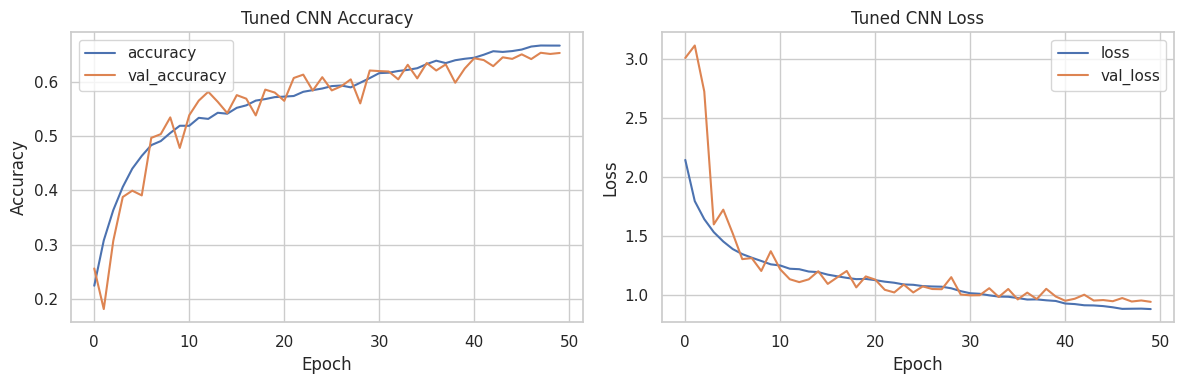

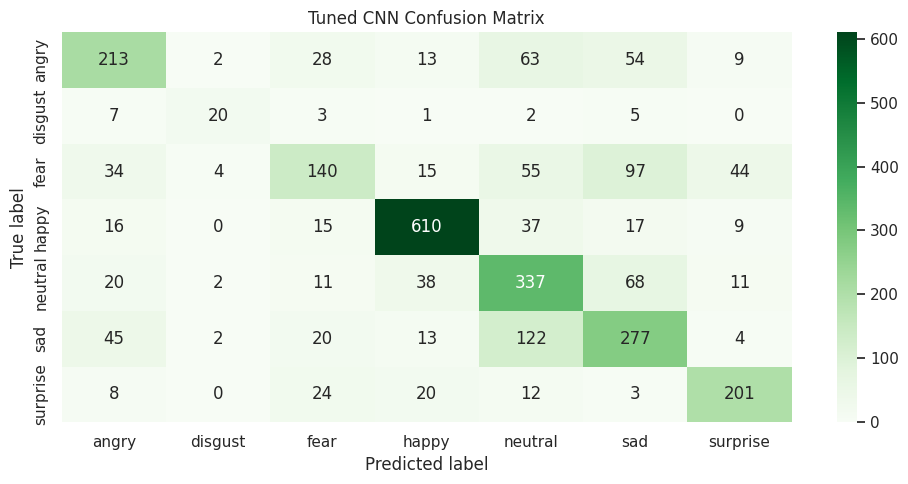

,model,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
1,reference_fer_cnn,tuning_validation,0.653581,0.645577,0.617968,0.625087,0.648975
0,baseline_cnn,tuning_validation,0.495093,0.437365,0.422597,0.410969,0.479664


In [ ]:
# Code Cell 56: Evaluate Tuned CNN Visually
# Visualize tuned CNN performance and compare it with the baseline.
# Review the tuned model curves for convergence and overfitting signs.
plot_training_history(tuned_history, 'Tuned CNN')

# Compare true and predicted emotions after tuned-CNN validation.
sns.heatmap(tuned_cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Tuned CNN Confusion Matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.tight_layout()
plt.show()

# Sort completed tuning results before the transfer-learning comparison is added.
results_so_far = pd.DataFrame(model_results.values()).sort_values('macro_f1', ascending=False)
display(results_so_far)


##### Which hyperparameter optimization technique have you used and why?

Manual tuning was guided by the saved outputs. The previous weighted CNN and EfficientNetB0 runs were weak, so the final CNN was changed to a reference-style FER architecture. The useful tuning decisions were normalized NumPy image arrays, realistic augmentation, 50 epochs, validation-based checkpointing, and reduced learning rate when validation loss stopped improving. Grid search was not used because it would be too expensive for a Colab deep learning notebook.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The reference-style CNN is evaluated on tuning validation during training. Its final-test result must be reported only after model selection is complete. Training and validation curves can indicate overfitting, but they do not replace the held-out final evaluation.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Accuracy measures overall correctness. Precision measures how reliable a predicted emotion is. Recall measures how many true examples of an emotion are found. F1-score balances precision and recall. Macro F1 is the main selection metric because it gives each of the seven classes equal importance despite class imbalance.

### ML Model - 3

In [ ]:
# Code Cell 57: Train Optional Transfer Learning Model
# Build transfer-learning datasets from the existing split arrays without mixing splits.
# EfficientNetB0 is a comparison model. It uses the same split protocol as the CNNs.
# Keep optional transfer-learning state separate so a failed comparison cannot stop the main notebook.
transfer_model = None
transfer_history = None
transfer_scores = None
train_rgb_ds = tuning_rgb_ds = test_rgb_ds = None

# Run transfer learning as an optional comparison because pretrained ImageNet features may not suit low-resolution grayscale faces.
try:
    # Convert the existing split arrays into EfficientNet-compatible datasets without changing split membership.
    def make_transfer_dataset(images, labels, image_size, shuffle=False):
        # Pair each image with its original label before mapping image preparation steps.
        dataset = tf.data.Dataset.from_tensor_slices((images, labels))

        # Prepare each grayscale FER image in the format required by the pretrained backbone.
        def prepare_transfer_image(image, label):
            # EfficientNet expects three channels, so repeat the grayscale channel as RGB.
            rgb_image = tf.image.grayscale_to_rgb(image)
            # Resize only for this transfer-learning branch; the custom CNN keeps the native 48 by 48 inputs.
            rgb_image = tf.image.resize(rgb_image, image_size)
            # Restore the 0 to 255 scale expected by the EfficientNet preprocessing built into this TensorFlow model.
            rgb_image = rgb_image * 255.0
            # Use one-hot labels because the transfer model uses categorical cross-entropy.
            one_hot_label = tf.one_hot(tf.cast(label, tf.int32), len(CLASS_NAMES))
            return rgb_image, one_hot_label

        # Apply the same deterministic conversion to every image in the requested split.
        dataset = dataset.map(prepare_transfer_image, num_parallel_calls=AUTOTUNE)
        if shuffle:
            dataset = dataset.shuffle(4000, seed=SEED, reshuffle_each_iteration=True)
        return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

    # Shuffle only model-training data; tuning and final datasets stay in a stable order.
    train_rgb_ds = make_transfer_dataset(X_train, y_train, TRANSFER_IMG_SIZE, shuffle=True)
    tuning_rgb_ds = make_transfer_dataset(X_tuning, y_tuning, TRANSFER_IMG_SIZE, shuffle=False)
    test_rgb_ds = make_transfer_dataset(X_test, y_test, TRANSFER_IMG_SIZE, shuffle=False)

    # Load ImageNet weights as a feature extractor for a fair transfer-learning comparison.
    base_model = EfficientNetB0(
        input_shape=(TRANSFER_IMG_SIZE[0], TRANSFER_IMG_SIZE[1], 3),
        include_top=False,
        weights='imagenet',
    )
    # Freeze the backbone first so the new classifier head can adapt without destroying pretrained features.
    base_model.trainable = False

    # Apply mild augmentation only while the model is training.
    rgb_augmentation = tf.keras.Sequential([
        layers.RandomFlip('horizontal', seed=SEED),
        layers.RandomRotation(0.04, seed=SEED),
        layers.RandomZoom(0.06, seed=SEED),
        layers.RandomTranslation(0.03, 0.03, seed=SEED),
    ], name='rgb_augmentation')

    # Add a small classification head on top of the frozen EfficientNet feature extractor.
    transfer_model = models.Sequential([
        layers.Input(shape=(TRANSFER_IMG_SIZE[0], TRANSFER_IMG_SIZE[1], 3)),
        rgb_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.30),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(len(CLASS_NAMES), activation='softmax', dtype='float32'),
    ], name='efficientnetb0_transfer')

    # Use the same accuracy and macro F1 metrics used for the CNN comparisons.
    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')],
    )

    # Checkpoint by tuning macro F1 so the saved transfer model follows the project selection metric.
    transfer_model_path = OUTPUT_DIR / 'deepfer_efficientnetb0_best.keras'
    transfer_callbacks = [
        EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
        ModelCheckpoint(str(transfer_model_path), monitor='val_macro_f1', mode='max', save_best_only=True),
    ]

    # Train the new classifier head before allowing any pretrained layers to update.
    transfer_head_history = transfer_model.fit(
        train_rgb_ds,
        validation_data=tuning_rgb_ds,
        epochs=TRANSFER_HEAD_EPOCHS,
        callbacks=transfer_callbacks,
        verbose=1,
    )

    # Fine-tune only the last backbone layers with a much smaller learning rate.
    base_model.trainable = True
    # Keep earlier generic image features frozen and expose only the final feature blocks to fine-tuning.
    for layer in base_model.layers[:-25]:
        layer.trainable = False
    # Keep batch-normalization statistics fixed because this dataset is much smaller than ImageNet.
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    # Recompile after changing trainable layers so TensorFlow applies the fine-tuning configuration.
    transfer_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.00002),
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.F1Score(average='macro', name='macro_f1')],
    )
    # Continue from the completed head-training epoch rather than restarting training history.
    transfer_fine_history = transfer_model.fit(
        train_rgb_ds,
        validation_data=tuning_rgb_ds,
        epochs=TRANSFER_HEAD_EPOCHS + TRANSFER_FINE_TUNE_EPOCHS,
        initial_epoch=len(transfer_head_history.history['loss']),
        callbacks=transfer_callbacks,
        verbose=1,
    )

    # Merge both training phases so the learning curves show the complete transfer experiment.
    combined_history = {}
    for key in set(transfer_head_history.history) | set(transfer_fine_history.history):
        combined_history[key] = transfer_head_history.history.get(key, []) + transfer_fine_history.history.get(key, [])
    transfer_history = SimpleNamespace(history=combined_history)

    # Reload the checkpoint with the best tuning macro F1 before recording comparison scores.
    if transfer_model_path.exists():
        transfer_model = tf.keras.models.load_model(str(transfer_model_path))

    # Store the transfer history with the other models for the shared comparison plots.
    model_histories['efficientnetb0_transfer'] = transfer_history
    # Evaluate transfer learning on tuning validation only; the held-out final set is not used for model selection.
    transfer_scores, transfer_report, transfer_cm = evaluate_model(
        transfer_model,
        tuning_rgb_ds,
        None,
        'efficientnetb0_transfer',
        CLASS_NAMES,
        dataset_name='tuning_validation',
    )
    display(pd.DataFrame([transfer_scores]))
    display(transfer_report)

# Allow the notebook to continue if GPU memory or pretrained-weight download prevents this optional experiment.
except Exception as error:
    print('Transfer learning was skipped safely.')
    print('Reason:', error)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/6
194/194 ━━━━━━━━━━━━━━━━━━━━ 45s 145ms/step - accuracy: 0.5846 - loss: 1.1480 - macro_f1: 0.4960 - val_accuracy: 0.2530 - val_loss: 2.6616 - val_macro_f1: 0.1311 - learning_rate: 0.0010
Epoch 2/6
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - accuracy: 0.5481 - loss: 1.3249 - macro_f1: 0.4596 - val_accuracy: 0.2545 - val_loss: 2.4427 - val_macro_f1: 0.1311 - learning_rate: 0.0010
Epoch 3/6
194/194 ━━━━━━━━━━━━━━━━━━━━ 25s 121ms/step - accuracy: 0.5567 - loss: 1.3300 - macro_f1: 0.4692 - val_accuracy: 0.2752 - val_loss: 2.6192 - val_macro_f1: 0.1586 - learning_rate: 0.0010
Epoch 4/6
194/194 ━━━━━━━━━━━━━━━━━━━━ 24s 116ms/step - accuracy: 0.5541 - loss: 1.3108 - macro_f1: 0.4613 - val_accuracy: 0.2654 - val_loss: 2.3496 - val_macro_f1: 0.1540 - learning_rate: 0.0010
Epoch 5/6
194/194 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.5165 - loss: 1.3544 - macro_f1: 0.4284 - val_accuracy: 0.2723 - val_loss: 2.6850 - val_macro_f1: 

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

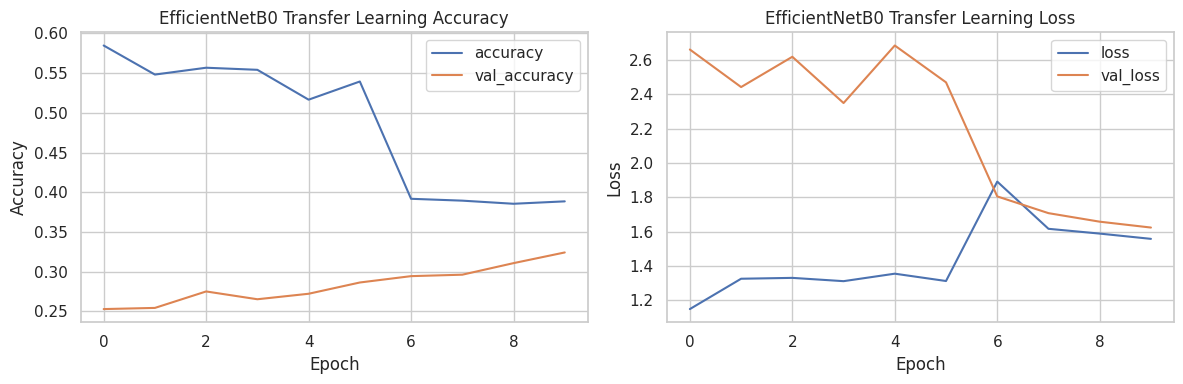

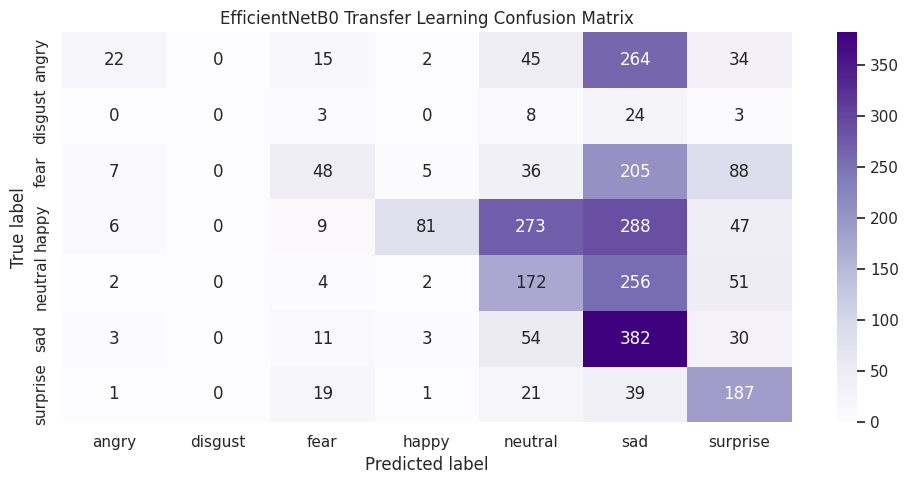

In [ ]:
# Code Cell 58: Evaluate Transfer Learning Visually
# Use the same evaluator so every model receives comparable tuning diagnostics.
# Show transfer-learning plots only if the model trained successfully.
if transfer_model is not None:
    # Plot transfer-learning history only when the optional model completed successfully.
    plot_training_history(transfer_history, 'EfficientNetB0 Transfer Learning')
    # Use the same confusion-matrix format as the CNN models for a fair visual comparison.
    sns.heatmap(transfer_cm, annot=True, fmt='d', cmap='Purples', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('EfficientNetB0 Transfer Learning Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()
else:
    print('No transfer learning chart because the transfer model was skipped.')


#### 2. Cross- Validation & Hyperparameter Tuning

,model,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,reference_fer_cnn,tuning_validation,0.653581,0.645577,0.617968,0.625087,0.648975
1,baseline_cnn,tuning_validation,0.495093,0.437365,0.422597,0.410969,0.479664
2,efficientnetb0_transfer,tuning_validation,0.324246,0.401155,0.305411,0.247932,0.269785


Selected model: reference_fer_cnn


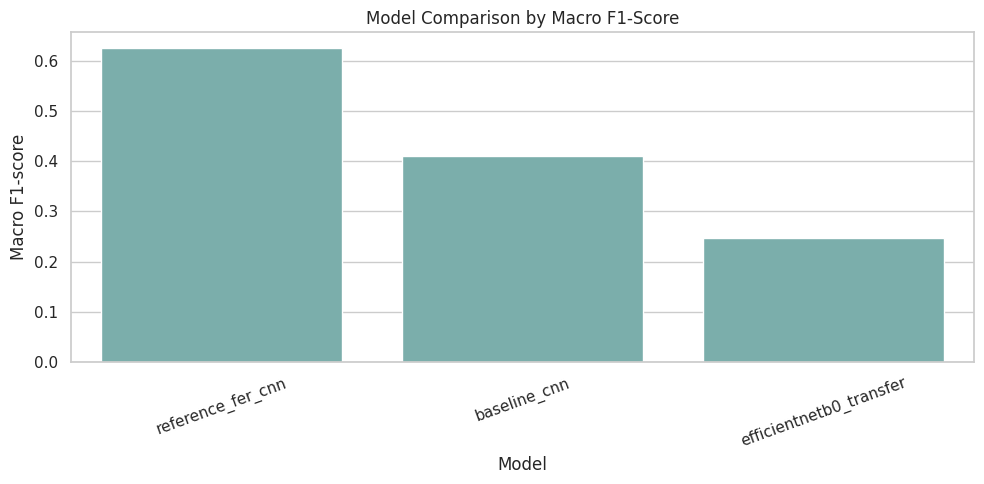

Model comparison interpretation:
- Best macro F1-score: 0.625 from reference_fer_cnn.
- The final choice is based on tuning macro F1-score, not only overall accuracy.
reference_fer_cnn output interpretation on untouched_final_test:
- Accuracy is 0.659, and macro F1-score is 0.615.
- Best handled emotion by F1-score: happy.
- Weakest handled emotion by F1-score: fear.
- The model predicted at least one sample for every emotion class.
- Prediction distribution is not dominated by one class.
- Macro F1 is important here because it treats every emotion class equally.


,label,predicted_count,prediction_share
0,angry,784,0.121100
1,disgust,65,0.010040
2,fear,582,0.089898
3,happy,1798,0.277726
4,neutral,1520,0.234785
5,sad,1141,0.176243
6,surprise,584,0.090207


Final test was evaluated once after model selection.


In [ ]:
# Code Cell 59: Compare Completed Models
# Rank completed models by tuning macro F1 before any final evaluation.
results_df = pd.DataFrame(model_results.values()).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(results_df)

if not results_df.empty:
    # Select the highest macro F1 model before reading held-out final metrics.
    selected_model_name = results_df.iloc[0]['model']
    selected_model = trained_models[selected_model_name]
    print('Selected model:', selected_model_name)

    # The bar chart makes model ranking easy to compare visually.
    sns.barplot(data=results_df, x='model', y='macro_f1', color='#72B7B2')
    plt.title('Model Comparison by Macro F1-Score')
    plt.xlabel('Model')
    plt.ylabel('Macro F1-score')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print('Model comparison interpretation:')
    print(f"- Best macro F1-score: {results_df.iloc[0]['macro_f1']:.3f} from {selected_model_name}.")
    print('- The final choice is based on tuning macro F1-score, not only overall accuracy.')

    # Evaluate the selected model once on the held-out final set after selection is fixed.
    final_test_scores, final_test_report, final_test_cm = evaluate_model(
        selected_model,
        X_test,
        y_test,
        selected_model_name,
        CLASS_NAMES,
        dataset_name='untouched_final_test',
        store_result=False
    )
    print('Final test was evaluated once after model selection.')


##### Which hyperparameter optimization technique have you used and why?

EfficientNetB0 was evaluated as a comparison model. It achieved 0.324 tuning accuracy and 0.248 macro F1, lower than both custom CNNs. This shows that pretrained ImageNet features were not automatically better for these small 48 by 48 grayscale facial-expression images.


##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Transfer learning is kept as an evidence-based comparison, not an automatic upgrade. In this run, its tuning macro F1 was 0.248, so it did not improve balanced performance and was not selected.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Model selection uses tuning-validation macro F1, supported by class-wise precision, recall, prediction distribution, and the confusion matrix. The held-out final set is evaluated once after selection and is not used to choose architecture, epochs, or callbacks.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The selected model is the reference-style FER CNN. I selected it using tuning macro F1-score because this metric gives equal importance to all seven emotions. On the held-out final set, it achieved 0.659 accuracy, 0.634 macro precision, 0.608 macro recall, and 0.615 macro F1-score.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The selected model learns image features through convolution layers. Early layers learn edges and simple curves. Deeper layers combine these patterns into facial parts such as eyes, eyebrows, cheeks, and mouth shapes. The notebook uses occlusion sensitivity for explainability: it hides small image regions and checks how much the prediction confidence drops. Regions that create a stronger confidence drop are more important for that prediction. This helps explain whether the model is focusing on meaningful face regions instead of random background noise.


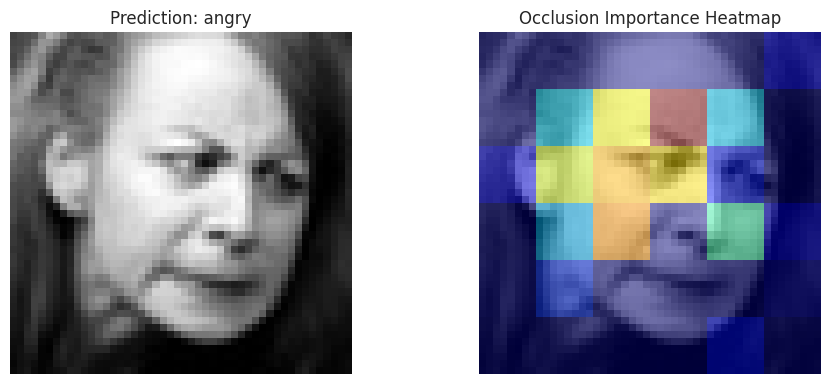

Occlusion interpretation:
- Brighter heatmap areas are regions where hiding pixels reduced confidence the most.
- For a useful emotion model, important regions should usually appear around eyes, eyebrows, cheeks, or mouth.


In [ ]:
# Code Cell 60: Explain One Prediction With Occlusion
# Use the selected model and matching test dataset for one simple explainability example.
selected_test_dataset = test_rgb_ds if selected_model_name == 'efficientnetb0_transfer' else test_ds
explain_images, explain_labels = next(iter(selected_test_dataset))
explain_image = explain_images[0:1]

# Get the model's original confidence for its predicted class.
base_probabilities = selected_model.predict(explain_image, verbose=0)[0]
predicted_class_id = int(np.argmax(base_probabilities))
base_score = float(base_probabilities[predicted_class_id])

# Hide small image patches one by one and measure confidence drop.
height, width = explain_image.shape[1], explain_image.shape[2]
patch_size = max(8, height // 6)
heatmap = np.zeros((height, width), dtype=np.float32)

for top in range(0, height, patch_size):
    for left in range(0, width, patch_size):
        bottom = min(top + patch_size, height)
        right = min(left + patch_size, width)
        occluded_image = explain_image.numpy().copy()
        occluded_image[:, top:bottom, left:right, :] = 0
        occluded_score = selected_model.predict(occluded_image, verbose=0)[0][predicted_class_id]
        heatmap[top:bottom, left:right] = base_score - float(occluded_score)

# Normalize the heatmap so stronger regions are easier to see.
heatmap = np.maximum(heatmap, 0)
if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

# Show the original image and the occlusion importance overlay.
image_to_show = explain_image[0].numpy()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
if image_to_show.shape[-1] == 1:
    axes[0].imshow(image_to_show.squeeze(), cmap='gray')
else:
    axes[0].imshow(np.clip(image_to_show / 255.0, 0, 1))
axes[0].set_title(f'Prediction: {CLASS_NAMES[predicted_class_id]}')
axes[0].axis('off')

if image_to_show.shape[-1] == 1:
    axes[1].imshow(image_to_show.squeeze(), cmap='gray')
else:
    axes[1].imshow(np.clip(image_to_show / 255.0, 0, 1))
axes[1].imshow(heatmap, cmap='jet', alpha=0.45)
axes[1].set_title('Occlusion Importance Heatmap')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Occlusion interpretation:')
print('- Brighter heatmap areas are regions where hiding pixels reduced confidence the most.')
print('- For a useful emotion model, important regions should usually appear around eyes, eyebrows, cheeks, or mouth.')


## ***8.*** ***Future Work (Optional)***

### Save the selected TensorFlow model in `.keras` format

The selected neural-network model is saved in TensorFlow's native `.keras` format. This format preserves the architecture and weights more reliably than pickle or joblib for this project. The matching CSV and JSON metadata record the model-selection split and final-test result.

In [ ]:
# Code Cell 61: Save Selected Model, Results, And Run Metadata
# Save the selected model and its metrics together to avoid mixing results between runs.
# Stop saving if selection or final evaluation has not completed.
if results_df.empty or 'final_test_scores' not in globals():
    raise ValueError('Model selection and the final test evaluation must finish before saving artifacts.')

# Use the selected model name in every saved artifact path.
best_model_name = selected_model_name
best_model = selected_model
best_model_path = OUTPUT_DIR / f'{best_model_name}_final.keras'
results_path = OUTPUT_DIR / 'deepfer_model_results.csv'
run_metadata_path = OUTPUT_DIR / 'deepfer_run_metadata.json'

# Keep tuning comparison rows and the final selected-model row in one CSV.
saved_results_df = pd.concat(
    [results_df, pd.DataFrame([final_test_scores])],
    ignore_index=True,
)
# Save the exact selected model used for final evaluation.
best_model.save(str(best_model_path))
saved_results_df.to_csv(results_path, index=False)

# Write the selection rule, split sizes, overlap checks, and final metrics as one run record.
run_metadata = {
    'selected_model': best_model_name,
    'selection_metric': 'macro_f1 on tuning_validation',
    'final_evaluation_split': 'untouched_final_test',
    'seed': int(SEED),
    'split_sizes': {
        'model_training': int(len(train_file_df)),
        'tuning_validation': int(len(tuning_file_df)),
        'untouched_final_test': int(len(test_file_df)),
    },
    'exact_hash_overlap': {
        'train_tuning': int(len(train_hashes & tuning_hashes)),
        'train_test': int(len(train_hashes & test_hashes)),
        'tuning_test': int(len(tuning_hashes & test_hashes)),
    },
    'final_test_metrics': {key: float(value) if isinstance(value, (int, float, np.floating)) else value for key, value in final_test_scores.items()},
}
# Store metadata beside the model and CSV so later reporting uses the same run.
run_metadata_path.write_text(json.dumps(run_metadata, indent=2), encoding='utf-8')

print('Selected model:', best_model_name)
print('Saved model path:', best_model_path)
print('Saved results path:', results_path)
print('Saved run metadata path:', run_metadata_path)


Selected model: reference_fer_cnn
Saved model path: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs/reference_fer_cnn_final.keras
Saved results path: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs/deepfer_model_results.csv
Saved run metadata path: /content/drive/MyDrive/Colab Notebooks/# specialization projects/5th project DeepFER Facial Emotion Recognition Using Deep Learning/outputs/deepfer_run_metadata.json


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


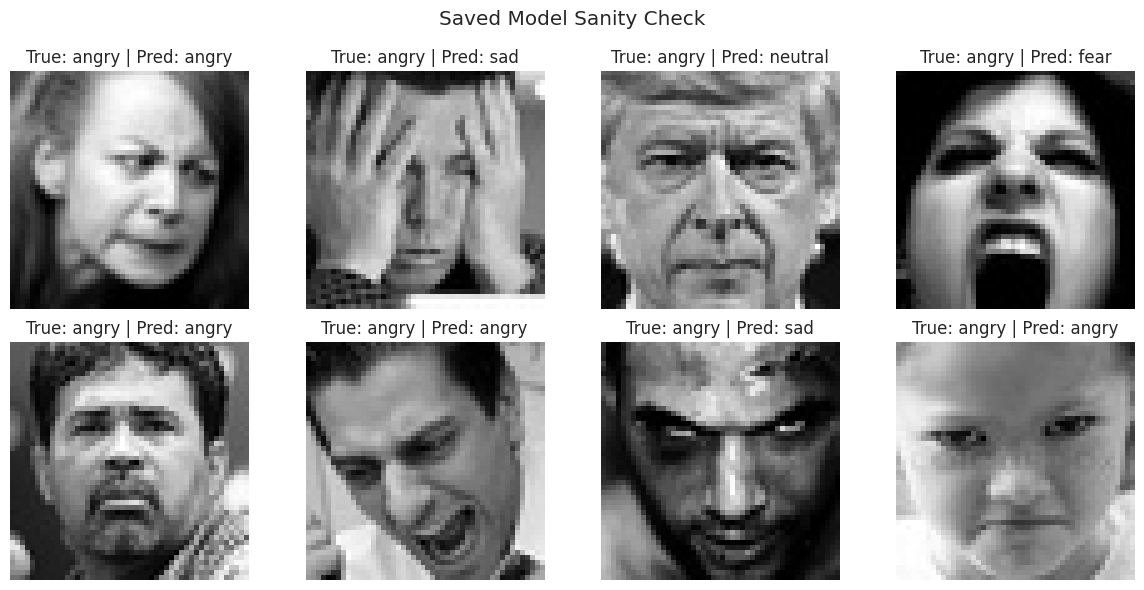

Sanity check interpretation:
- Correct predictions show where the saved model is working as expected.
- Wrong predictions should be compared with the face image because some expressions are visually similar.


In [ ]:
# Code Cell 62: Load Saved Model And Sanity Check
# Load the saved best model to confirm the saved file works after training.
loaded_best_model = tf.keras.models.load_model(str(best_model_path))

# Use the correct test dataset shape for the selected model type.
best_test_dataset = test_rgb_ds if best_model_name == 'efficientnetb0_transfer' else test_ds
sample_batch_images, sample_batch_labels = next(iter(best_test_dataset))

# Predict a small batch from the held-out final dataset.
sample_probabilities = loaded_best_model.predict(sample_batch_images[:8], verbose=0)
sample_predictions = np.argmax(sample_probabilities, axis=1)

# Display true and predicted labels for a quick human-readable check.
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, image, true_label, predicted_label in zip(axes.ravel(), sample_batch_images[:8], sample_batch_labels[:8], sample_predictions):
    image_to_show = image.numpy()
    if image_to_show.shape[-1] == 1:
        axis.imshow(image_to_show.squeeze(), cmap='gray')
    else:
        axis.imshow(np.clip(image_to_show / 255.0, 0, 1))
    axis.set_title(f'True: {CLASS_NAMES[int(true_label)]} | Pred: {CLASS_NAMES[int(predicted_label)]}')
    axis.axis('off')

plt.suptitle('Saved Model Sanity Check')
plt.tight_layout()
plt.show()

print('Sanity check interpretation:')
print('- Correct predictions show where the saved model is working as expected.')
print('- Wrong predictions should be compared with the face image because some expressions are visually similar.')


## Final Result Review

The reference-style FER CNN remained consistent between tuning and final evaluation. Its tuning macro F1-score was 0.625, and its final macro F1-score was 0.615. The small difference suggests that the selected model did not depend only on the tuning split.

Happy was the strongest class, while fear was the weakest. The model still produced predictions for every emotion and did not collapse into one majority class. The final accuracy of 0.659 and macro F1-score of 0.615 are realistic for a small, imbalanced FER2013-style dataset.

## Limitations And Responsible Use

This dataset contains small 48 by 48 grayscale face crops and has strong class imbalance, especially for disgust. Exact hash checks reduce duplicate leakage, but the dataset has no person identifier, so same-person or near-duplicate overlap cannot be ruled out. Results may also vary across lighting, pose, age, ethnicity, image quality, and expression intensity.

The model is a classroom image-classification prototype. It is not validated for clinical assessment, mental-health diagnosis, hiring, security decisions, or emotion-based profiling. A real application would need consent, privacy safeguards, demographic evaluation, latency testing, monitoring, and separate deployment validation.

# **Conclusion**

I completed an end-to-end facial emotion recognition workflow covering data checks, duplicate handling, preprocessing, augmentation, baseline modeling, a deeper CNN, transfer learning, evaluation, explainability, and model saving.

The reference-style FER CNN gave the best balanced tuning result, so I selected it as the final model. It achieved 0.659 accuracy and 0.615 macro F1-score on the held-out final set. Happy was handled best, while fear remained the most difficult emotion.

The result is useful as a college deep-learning project, but it still has practical limitations. The images are small, the classes are imbalanced, and the dataset does not include person identifiers or demographic labels. Because of these limits, I would treat the model as a learning prototype rather than a clinical, security, or high-stakes decision system.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***